# POSTMATCH — EDA i modelowanie
Notebook dla danych post-match: wpływ statystyk z meczu na win_A.


## 1) Importy, konfiguracja i funkcje pomocnicze


In [83]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import  cross_val_score, train_test_split


PROJECT_DIR = Path.cwd().resolve()
DATA_FILE = PROJECT_DIR / "data" / "processed_postmatch.csv"
TARGET = "win_A"

FIGURES_DIR = PROJECT_DIR / "figures"
EDA_DIR = FIGURES_DIR / "eda_postmatch"
MODELING_DIR = FIGURES_DIR / "modeling_postmatch"

EDA_DIR.mkdir(parents=True, exist_ok=True)
MODELING_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


In [84]:
def detect_sep(path: Path) -> str:
    first_line = path.read_text(encoding="utf-8-sig", errors="replace").splitlines()[0]
    return ";" if first_line.count(";") > first_line.count(",") else ","


def plot_path(section: str, filename: str) -> Path:
    if section in {"eda", "eda_postmatch"}:
        return EDA_DIR / filename
    if section == "modeling":
        return MODELING_DIR / filename
    if section == "tables":
        return TABLES_DIR / filename
    raise ValueError(f"Nieznana sekcja: {section}")


def build_features_all(df_in: pd.DataFrame) -> list[str]:
    non_features = {TARGET, "game_id", "season", "team_A", "team_B"}
    return [
        c for c in df_in.columns
        if c not in non_features and pd.api.types.is_numeric_dtype(df_in[c])
    ]


def prepare_xy(df_in: pd.DataFrame, features: list[str]):
    features = [c for c in features if c in df_in.columns]
    X = df_in[features].apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(df_in[TARGET], errors="coerce")

    mask = X.notna().all(axis=1) & y.notna()
    return X.loc[mask], y.loc[mask].astype(int)


def remove_constant_features(df_in, features, label="cechy"):
    valid, dropped = [], []

    for f in features:
        if f not in df_in.columns:
            dropped.append(f)
            continue

        s = pd.to_numeric(df_in[f], errors="coerce")
        if s.nunique(dropna=True) <= 1:
            dropped.append(f)
        else:
            valid.append(f)

    if dropped:
        print(f"[{label}] usunieto (stale): {dropped}")

    return valid




## 2) Wczytanie danych

In [85]:
sep = detect_sep(DATA_FILE)
df = pd.read_csv(DATA_FILE, sep=sep, encoding="utf-8-sig")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

FEATURES_ALL = build_features_all(df)

teams = sorted(set(df["team_A"]).union(set(df["team_B"])))
data_summary = pd.DataFrame(
    {
        "Wskaźnik": [
            "Liczba meczów",
            "Liczba kolumn",
            "Liczba drużyn",
            "Liczba sezonów",
            "Udział win_A = 1",
        ],
        "Wartość": [
            len(df),
            df.shape[1],
            len(teams),
            df["season"].nunique(),
            round(df[TARGET].mean(), 4),
        ],
    }
)

print(data_summary.to_string())
druzyny_str = ", ".join(teams)
print(f"Druzyny ({len(teams)}): {druzyny_str}")


           Wskaźnik   Wartość
0     Liczba meczów  1776.000
1     Liczba kolumn    18.000
2     Liczba drużyn    24.000
3    Liczba sezonów    11.000
4  Udział win_A = 1     0.549
Druzyny (24): Akademia Tarnów, Atom Trefl Sopot, BKS Bielsko-Biała, Budowlani Toruń, Budowlani Łódź, Chemik Police, Developres Rzeszów, Joker Świecie, KSZO Ostrowiec, LOS Nowy Dwór Mazowiecki, Legionovia, MKS Dąbrowa Górnicza, MKS Kalisz, Muszynianka Muszyna, PTPS Piła, Pałac Bydgoszcz, Proxima Kraków, Radomka Radom, Sokół Mogilno, Stal Mielec, UNI Opole, Volley Wrocław, Wisła Warszawa, ŁKS Commercecon Łódź


## 3) EDA — analiza danych

win_A
1    975
0    801
Name: count, dtype: int64


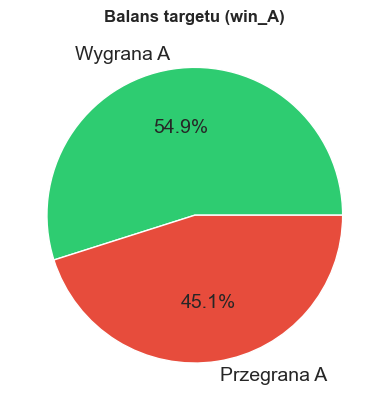

In [86]:
print(df[TARGET].value_counts())
df[TARGET].value_counts().plot.pie(autopct="%1.1f%%", labels=["Wygrana A", "Przegrana A"], colors=["#2ECC71", "#E74C3C"], textprops={"fontsize": 14})
plt.ylabel("")
plt.title("Balans targetu (win_A)", fontweight="bold")
plt.savefig(plot_path("eda", "target_balance.png"), dpi=150, bbox_inches="tight")
plt.show()


  Ogólny win rate gospodarzy (A): 54.9%
  Test dwumianowy H0: win_rate = 0.5, p = 0.0000
  Wniosek: przewaga istotna statystycznie
  (975 wygranych na 1776 meczów)
  Win rate gospodarzy wg sezonu:
           Win rate  Mecze
season                    
2015/2016  0.588957    163
2016/2017  0.625641    195
2017/2018  0.574257    202
2018/2019  0.528662    157
2019/2020  0.519380    129
2020/2021  0.503106    161
2021/2022  0.560510    157
2022/2023  0.477941    136
2023/2024  0.537975    158
2024/2025  0.573248    157
2025/2026  0.509317    161
  Prawdziwa przewaga hali (win rate u siebie - win rate na wyjeździe):
                          Liczba meczów  Win rate u siebie (%)  Win rate na wyjeździe (%)  Przewaga hali (p.p.)
Budowlani Toruń                      53                   51.9                       23.1                  28.8
Muszynianka Muszyna                  82                   58.5                       31.7                  26.8
KSZO Ostrowiec                      108      

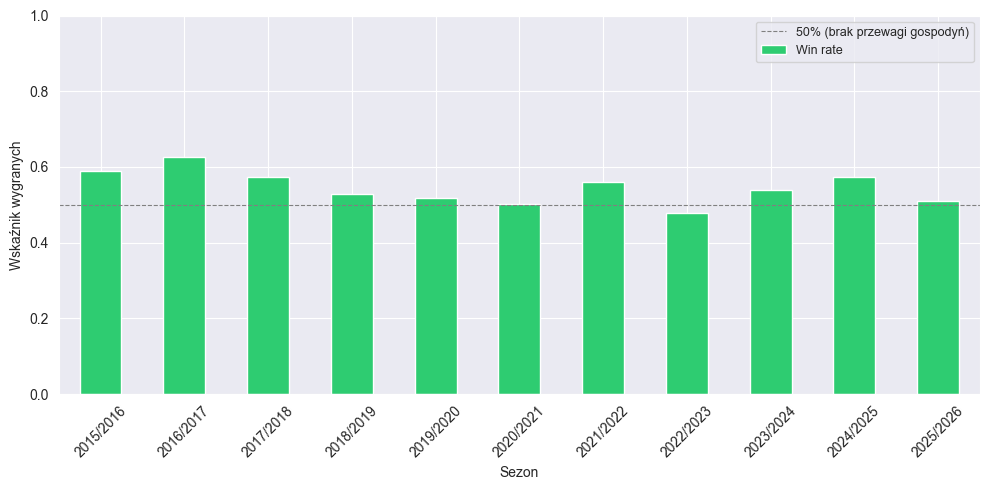

In [87]:
# === Analiza przewagi gospodarzy ===

home_win_rate = df["win_A"].mean()
print(f"  Ogólny win rate gospodarzy (A): {home_win_rate:.1%}")
from scipy.stats import binomtest
p_val = binomtest((df["win_A"] == 1).sum(), len(df), p=0.5).pvalue
print(f"  Test dwumianowy H0: win_rate = 0.5, p = {p_val:.4f}")
print(f"  Wniosek: {'przewaga istotna statystycznie' if p_val < 0.05 else 'brak podstaw do odrzucenia H0'}")
wins = (df["win_A"] == 1).sum()
print(f"  ({wins} wygranych na {len(df)} meczów)")

# Wg sezonu
print("  Win rate gospodarzy wg sezonu:")
season_home = df.groupby("season")["win_A"].agg(["mean", "count"])
season_home.columns = ["Win rate", "Mecze"]
print(season_home.to_string())

# Prawdziwa przewaga hali (win rate u siebie vs na wyjeździe)
print("  Prawdziwa przewaga hali (win rate u siebie - win rate na wyjeździe):")
team_home = df.groupby("team_A")["win_A"].mean()  # win rate jako gospodarz
team_away = 1 - df.groupby("team_B")["win_A"].mean()  # win rate na wyjeździe (team_B przegrywa gdy win_A=1)
team_ha = pd.DataFrame({
    "Win rate u siebie": team_home,
    "Win rate na wyjeździe": team_away,
})
# Liczba meczów ogółem (u siebie + na wyjeździe)
team_home_count = df.groupby("team_A")["win_A"].count()
team_away_count = df.groupby("team_B")["win_A"].count()
team_ha["Liczba meczów"] = team_home_count + team_away_count

team_ha["Przewaga hali"] = team_ha["Win rate u siebie"] - team_ha["Win rate na wyjeździe"]
team_ha = team_ha.sort_values("Przewaga hali", ascending=False)
# Przestawienie kolejności kolumn
team_ha = team_ha[["Liczba meczów", "Win rate u siebie", "Win rate na wyjeździe", "Przewaga hali"]]
# Konwersja win rate na procenty
for col in ["Win rate u siebie", "Win rate na wyjeździe", "Przewaga hali"]:
    team_ha[col] = (team_ha[col] * 100).round(1)
team_ha.columns = ["Liczba meczów", "Win rate u siebie (%)", "Win rate na wyjeździe (%)", "Przewaga hali (p.p.)"]
print(team_ha.to_string())

# Wykres
fig, ax = plt.subplots(figsize=(10, 5))

# Win rate wg sezonu (tylko ten panel)
season_home["Win rate"].plot.bar(ax=ax, color="#2ECC71", edgecolor="white")
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50% (brak przewagi gospodyń)")
# Tytuł usunięty — podpis pod rysunkiem w dokumencie
ax.set_xlabel("Sezon")
ax.set_ylabel("Wskaźnik wygranych")
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(plot_path("eda", "home_advantage.png"), dpi=150, bbox_inches="tight")
plt.show()


  Liczba meczów 5-setowych: 400
  Win rate gospodarzy w tie-breakach: 53.5%
  (214 wygranych na 400 meczów)
  Dla porównania – win rate gospodarzy ogólnie: 54.9%
  Różnica (tie-break vs ogółem): -1.4%
  Win rate gospodarzy w tie-breakach wg sezonu:
           Win rate  Mecze
season                    
2015/2016  0.666667     30
2016/2017  0.700000     50
2017/2018  0.479167     48
2018/2019  0.463415     41
2019/2020  0.480000     25
2020/2021  0.384615     39
2021/2022  0.564103     39
2022/2023  0.538462     26
2023/2024  0.406250     32
2024/2025  0.631579     38
2025/2026  0.531250     32
  Porównanie win rate gospodarzy wg liczby setów:
                     Win rate gospodarzy  Liczba meczów
3 sety                          0.567775            782
4 sety                          0.533670            594
5 setów (tie-break)             0.535000            400


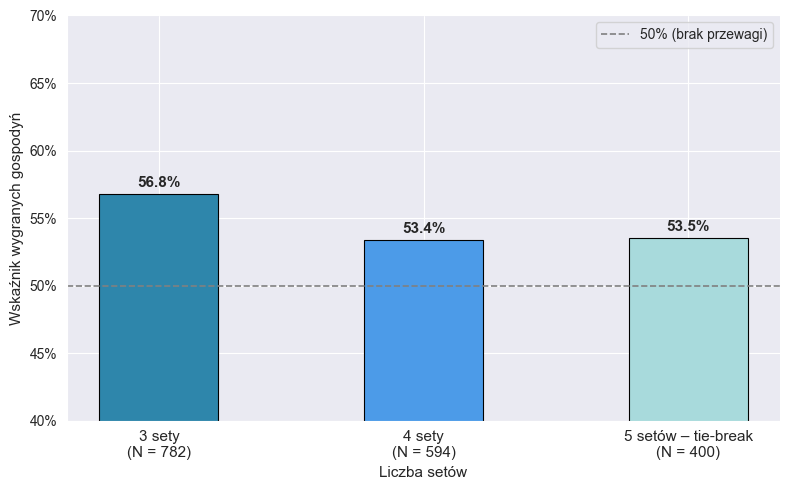

Test dwumianowy dla tie-breaków (H0: win_rate = 0.5): p-value = 0.1769
Wniosek: W meczach 5-setowych przewaga własnego boiska NIE JEST istotna statystycznie.
Z-test różnicy proporcji (3-4 sety vs tie-break): p-value = 0.5230


In [88]:
# === Przewaga gospodarzy w tie-breakach (5 set) ===

df_tb = df[df["number_of_sets"] == 5].copy()
print(f"  Liczba meczów 5-setowych: {len(df_tb)}")

tb_win_rate = df_tb["win_A"].mean()
print(f"  Win rate gospodarzy w tie-breakach: {tb_win_rate:.1%}")
wins_tb = (df_tb["win_A"] == 1).sum()
print(f"  ({wins_tb} wygranych na {len(df_tb)} meczów)")

all_home = df["win_A"].mean()
print(f"  Dla porównania – win rate gospodarzy ogólnie: {all_home:.1%}")
print(f"  Różnica (tie-break vs ogółem): {tb_win_rate - all_home:+.1%}")

# Wg sezonu
print("  Win rate gospodarzy w tie-breakach wg sezonu:")
tb_season = df_tb.groupby("season")["win_A"].agg(["mean", "count"])
tb_season.columns = ["Win rate", "Mecze"]
print(tb_season.to_string())

# Porównanie: win rate wg liczby setów
comparison = df.groupby("number_of_sets")["win_A"].agg(["mean", "count"])
comparison.index = ["3 sety", "4 sety", "5 setów (tie-break)"]
comparison.columns = ["Win rate gospodarzy", "Liczba meczów"]
print("  Porównanie win rate gospodarzy wg liczby setów:")
print(comparison.to_string())

# Wykres porównawczy
fig, ax = plt.subplots(figsize=(8, 5))

# Używamy pojedynczych cudzysłowów wewnątrz f-string, by uniknąć problemów z \" 
n3 = int(comparison.loc['3 sety', 'Liczba meczów'])
n4 = int(comparison.loc['4 sety', 'Liczba meczów'])
n5 = int(comparison.loc['5 setów (tie-break)', 'Liczba meczów'])
categories = [
    f"3 sety\n(N = {n3})",
    f"4 sety\n(N = {n4})",
    f"5 setów – tie-break\n(N = {n5})",
]
values = comparison["Win rate gospodarzy"].values

x = np.arange(len(categories))
bars = ax.bar(x, values, width=0.45, color=["#2E86AB", "#4C9BE8", "#A8DADC"],
               edgecolor="black", linewidth=0.8)

# Etykiety wartości na słupkach
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
            f"{val:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Linia 50%
ax.axhline(0.50, color="gray", linestyle="--", linewidth=1.2, label="50% (brak przewagi)")

# Tytuł usunięty — podpis pod rysunkiem w pracy
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_xlabel("Liczba setów", fontsize=11)
ax.set_ylabel("Wskaźnik wygranych gospodyń", fontsize=11)
ax.set_ylim(0.40, 0.70)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(plot_path("eda", "home_advantage_tiebreak.png"), dpi=300, bbox_inches="tight")
plt.show()
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import binomtest

# 1. Sprawdzenie istotności HA wyłącznie dla tie-breaków
wins_tb = (df_tb["win_A"] == 1).sum()
n_tb = len(df_tb)
p_val_tb = binomtest(wins_tb, n_tb, p=0.5).pvalue

print(f"Test dwumianowy dla tie-breaków (H0: win_rate = 0.5): p-value = {p_val_tb:.4f}")
if p_val_tb > 0.05:
    print("Wniosek: W meczach 5-setowych przewaga własnego boiska NIE JEST istotna statystycznie.")

# 2. Porównanie proporcji 3-4 sety vs 5 setów
df_34 = df[df["number_of_sets"] < 5]
wins_34 = (df_34["win_A"] == 1).sum()
n_34 = len(df_34)

# Z-test dla dwóch proporcji
count = np.array([wins_34, wins_tb])
nobs = np.array([n_34, n_tb])
stat, pval_prop = proportions_ztest(count, nobs)

print(f"Z-test różnicy proporcji (3-4 sety vs tie-break): p-value = {pval_prop:.4f}")


### 3.1.Braki danych

Sprawdzamy, które cechy mają braki i ile wierszy zostanie odrzuconych przez `dropna` w modelu.

In [89]:
nan_counts = df.isna().sum()
nan_table = (
    nan_counts[nan_counts > 0]
    .rename("Braki")
    .reset_index()
    .rename(columns={"index": "Kolumna"})
    .sort_values("Braki", ascending=False)
)

X_check, y_check = prepare_xy(df, FEATURES_ALL)
completeness_summary = pd.DataFrame(
    {
        "Wskaźnik": [
            "Łącznie wierszy",
            "Po dropna (wszystkie cechy)",
            "Utracone wiersze",
            "Utracony odsetek",
        ],
        "Wartość": [
            len(df),
            len(X_check),
            len(df) - len(X_check),
            f"{((len(df) - len(X_check)) / len(df) * 100):.1f}%",
        ],
    }
)

if nan_table.empty:
    print("Wszystkie cechy kompletne")
else:
    print(nan_table.to_string())

print(completeness_summary.to_string())


Wszystkie cechy kompletne
                      Wskaźnik Wartość
0              Łącznie wierszy    1776
1  Po dropna (wszystkie cechy)    1776
2             Utracone wiersze       0
3             Utracony odsetek    0.0%


                      avg_diff_atk_eff  avg_diff_blk_per_set  avg_diff_srv_eff  avg_diff_rec_pos_pct  avg_num_sets  avg_is_playoff  avg_diff_opp_errors_share  win_rate  matches
team_A                                                                                                                                                                          
Chemik Police                   0.1172                0.6367            0.0278                6.0455        3.5909          0.1948                    -0.0264    0.8117      154
Developres Rzeszów              0.1011                0.5910            0.0237                2.6296        3.7469          0.2346                    -0.0253    0.7840      162
ŁKS Commercecon Łódź            0.0751                0.5070            0.0093               -1.0357        3.7643          0.2000                    -0.0130    0.7357      140
Budowlani Łódź                  0.0719                0.6880            0.0158                2.6013        3.7059 

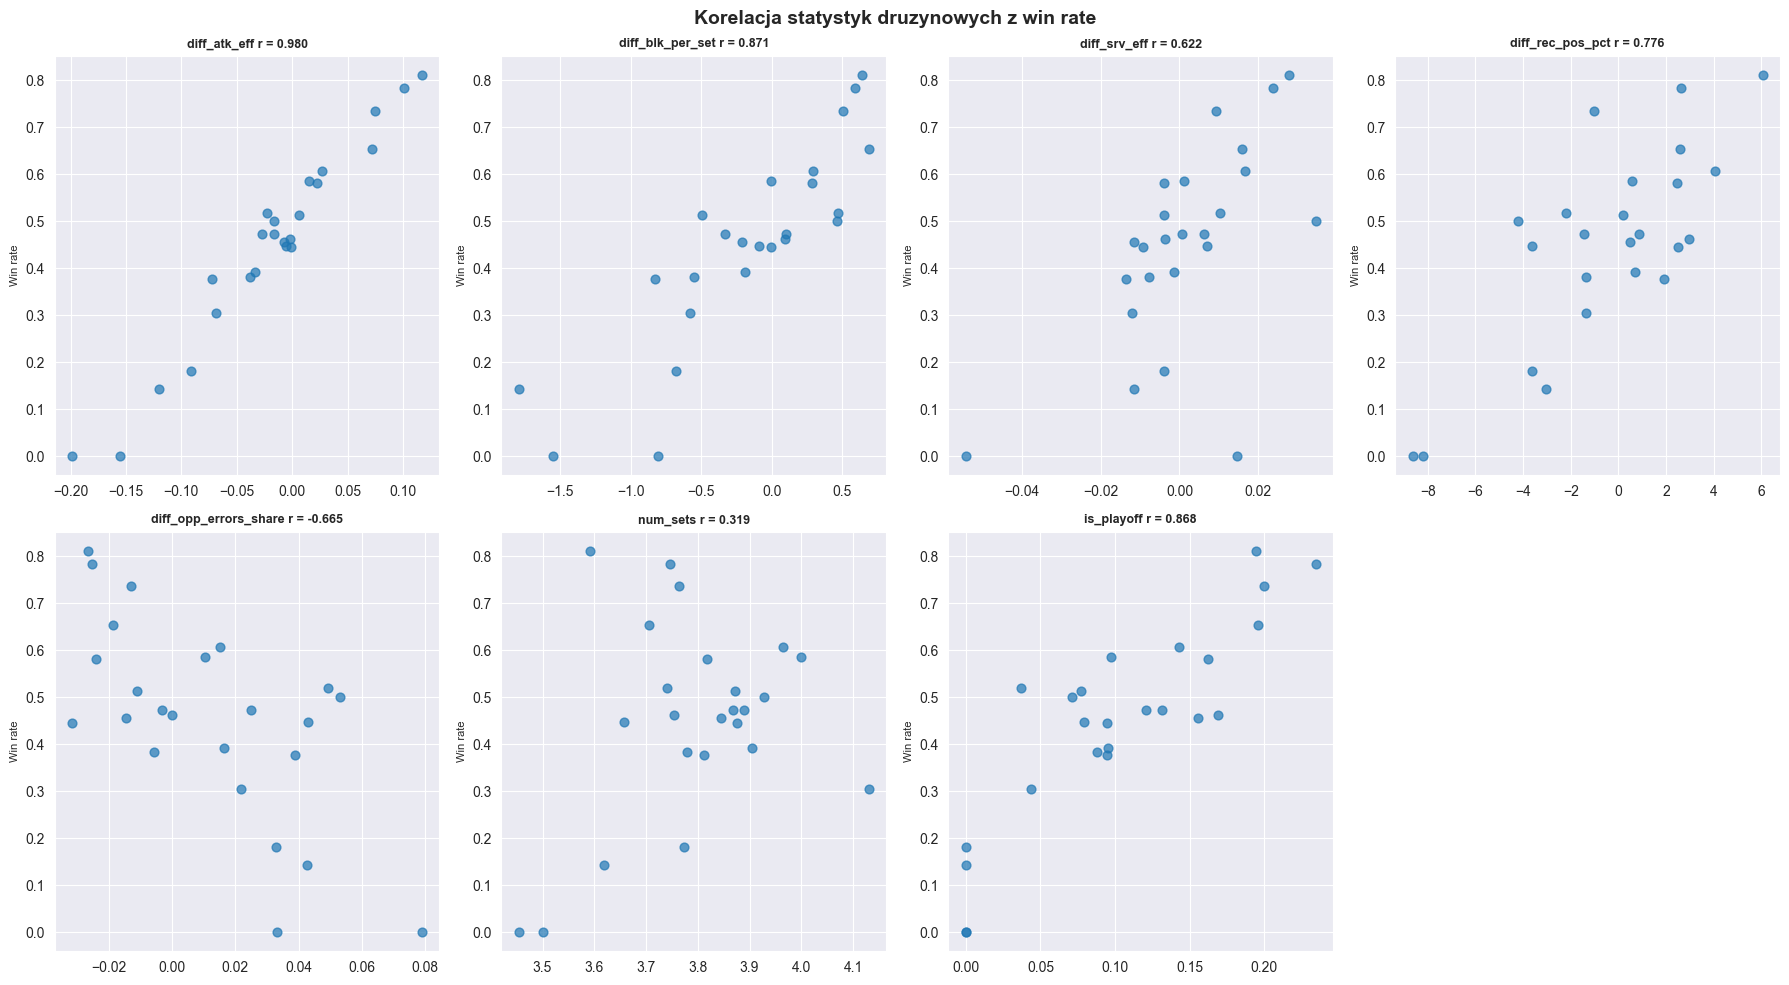

In [90]:
# === Statystyki druzynowe z originalnego df ===


# Uzywamy df bezposrednio, zamiast df_profiles_base, zeby miec wszystkie diff_* kolumny
team_stats = (
    df.groupby("team_A")
    .agg(
        avg_diff_atk_eff=("diff_atk_eff", "mean"),
        avg_diff_blk_per_set=("diff_blk_per_set", "mean"),
        avg_diff_srv_eff=("diff_srv_eff", "mean"),
        avg_diff_rec_pos_pct=("diff_rec_pos_pct", "mean"),
        avg_num_sets=("number_of_sets", "mean"),
        avg_is_playoff=("is_playoff", "mean"),
        avg_diff_opp_errors_share=("diff_opp_errors_share", "mean"),

        win_rate=("win_A", "mean"),
        matches=("win_A", "count"),
    )
    .sort_values("win_rate", ascending=False)
)

print(team_stats.head(10).round(4).to_string())

# === Scatter plot — wszystkie cechy SET1 vs win rate ===
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
all_feats_team = ["diff_atk_eff", "diff_blk_per_set", "diff_srv_eff",
                  "diff_rec_pos_pct", "diff_opp_errors_share",
                  "num_sets", "is_playoff"]
for ax, feat in zip(axes.flatten(), all_feats_team):
    col = f"avg_{feat}"
    if col in team_stats.columns:
        team_stats.plot.scatter(x=col, y="win_rate", ax=ax, alpha=0.7, s=40)
        corr_val = team_stats[col].corr(team_stats["win_rate"])
        ax.set_title(f'{feat} r = {corr_val:.3f}', fontsize=9, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("Win rate", fontsize=8)
        
for i_ax in range(len(all_feats_team), len(axes.flatten())):
    axes.flatten()[i_ax].set_visible(False)

plt.suptitle("Korelacja statystyk druzynowych z win rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(plot_path("eda", "team_stats_vs_winrate.png"), dpi=150, bbox_inches="tight")
plt.show()


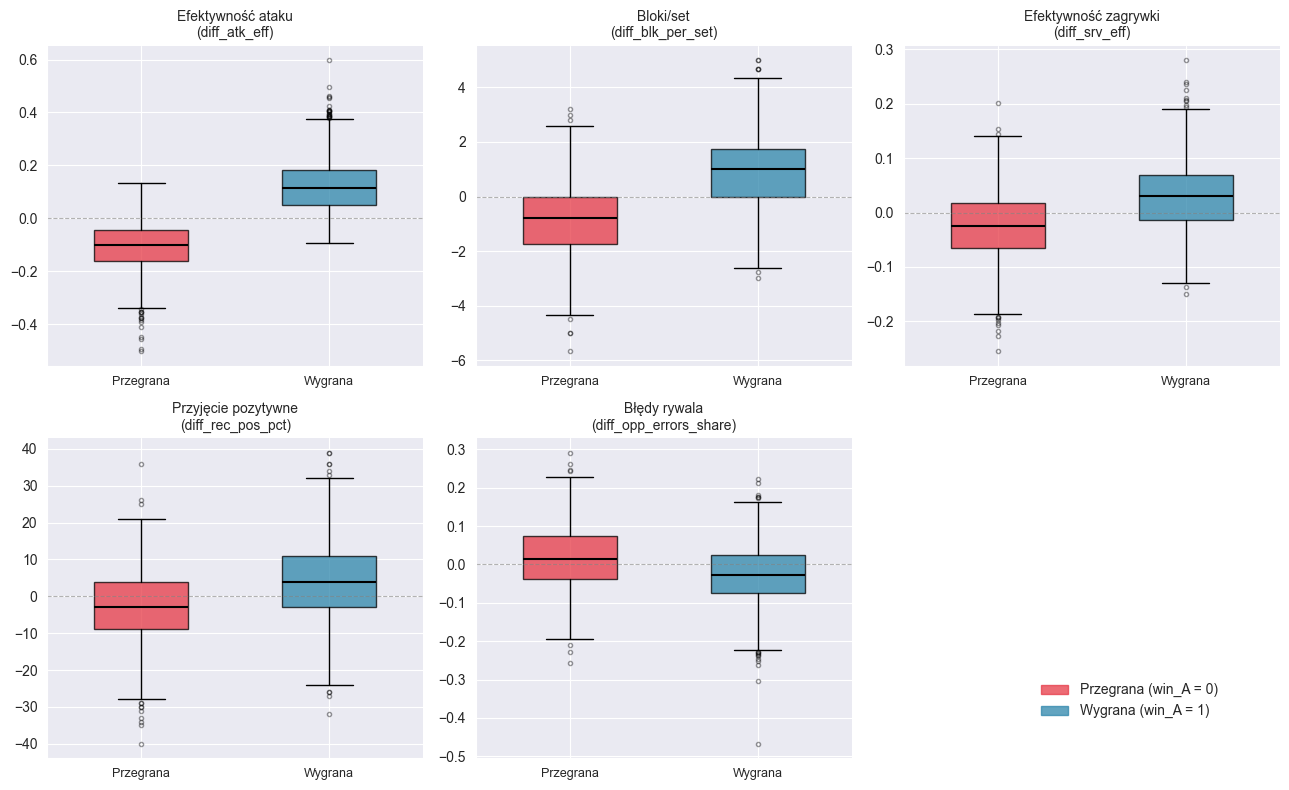

LICZBA SETOW A WYNIK MECZU


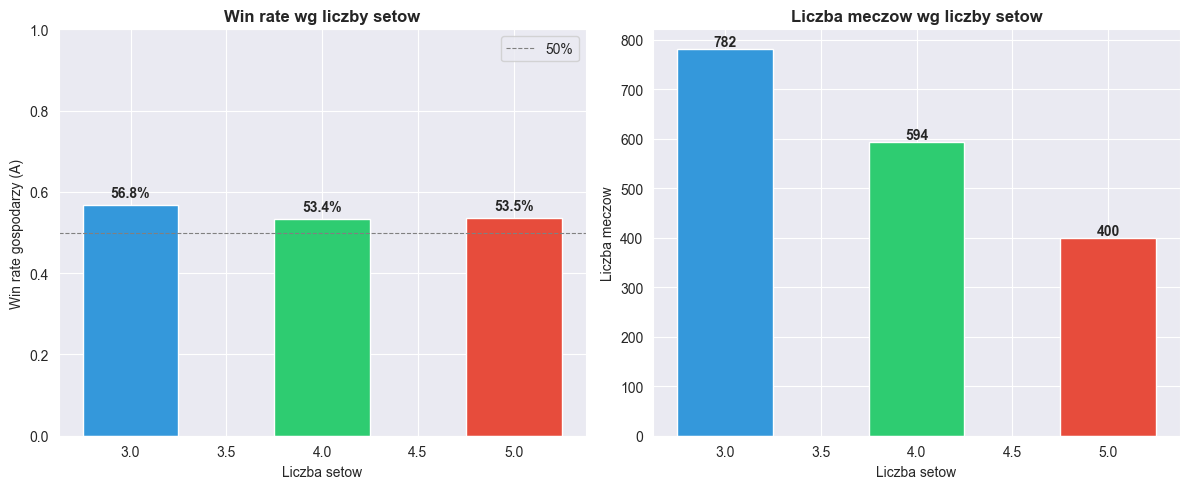

PLAYOFF A WYNIK MECZU


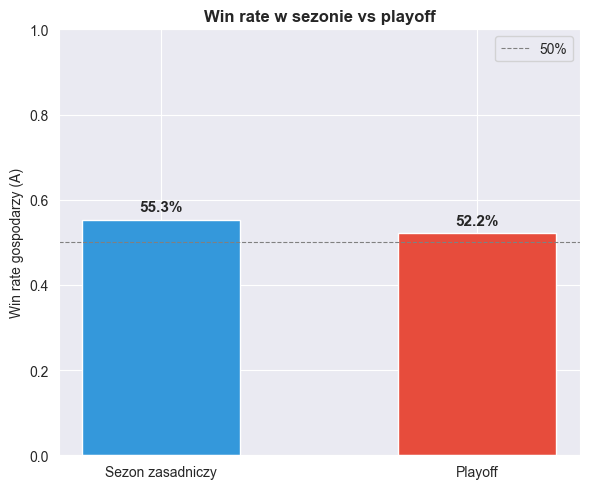

  Mecze w sezonie: 1525
  Mecze w playoff: 251


In [91]:
# === Box ploty diff_ vs win/loss ===
import matplotlib.patches as mpatches


features = [
    ("diff_atk_eff",        "Efektywność ataku\n(diff_atk_eff)"),
    ("diff_blk_per_set",    "Bloki/set\n(diff_blk_per_set)"),
    ("diff_srv_eff",        "Efektywność zagrywki\n(diff_srv_eff)"),
    ("diff_rec_pos_pct",    "Przyjęcie pozytywne\n(diff_rec_pos_pct)"),
    ("diff_opp_errors_share","Błędy rywala\n(diff_opp_errors_share)"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes_flat = axes.flatten()

colors = {0: "#E63946", 1: "#2E86AB"}
labels = {0: "Przegrana (0)", 1: "Wygrana (1)"}

for i, (col, title) in enumerate(features):
    ax = axes_flat[i]
    data = [df.loc[df["win_A"] == v, col].dropna() for v in [0, 1]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(linewidth=1),
                    capprops=dict(linewidth=1),
                    flierprops=dict(marker="o", markersize=3, alpha=0.4))
    for patch, v in zip(bp["boxes"], [0, 1]):
        patch.set_facecolor(colors[v])
        patch.set_alpha(0.75)
    # Tytuł usunięty — podpis pod rysunkiem w dokumencie
    ax.set_title(title, fontsize=10)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Przegrana", "Wygrana"], fontsize=9)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Ukryj 6. pusty subplot
axes_flat[5].set_visible(False)

# Legenda wspólna
patch0 = mpatches.Patch(color=colors[0], alpha=0.75, label="Przegrana (win_A = 0)")
patch1 = mpatches.Patch(color=colors[1], alpha=0.75, label="Wygrana (win_A = 1)")
fig.legend(handles=[patch0, patch1], loc="lower right",
           bbox_to_anchor=(0.95, 0.08), fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig(plot_path("eda", "boxplot_diff_vs_win.png"), dpi=300, bbox_inches="tight")
plt.show()

# number_of_sets — rozklad wygranych wg liczby setow
print("LICZBA SETOW A WYNIK MECZU")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Win rate wedlug liczby setow
sets_winrate = df.groupby("number_of_sets")["win_A"].mean()
sets_count = df.groupby("number_of_sets")["win_A"].count()

axes[0].bar(sets_winrate.index, sets_winrate.values, 
           color=["#3498DB", "#2ECC71", "#E74C3C"], edgecolor="white", width=0.5)
axes[0].axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
axes[0].set_xlabel("Liczba setow")
axes[0].set_ylabel("Win rate gospodarzy (A)")
axes[0].set_title("Win rate wg liczby setow", fontweight="bold")
axes[0].set_ylim(0, 1)
for x, y in zip(sets_winrate.index, sets_winrate.values):
    axes[0].text(x, y + 0.02, f"{y:.1%}", ha="center", fontsize=10, fontweight="bold")
axes[0].legend()

# Licznosc meczow wedlug liczby setow
axes[1].bar(sets_count.index, sets_count.values, 
           color=["#3498DB", "#2ECC71", "#E74C3C"], edgecolor="white", width=0.5)
axes[1].set_xlabel("Liczba setow")
axes[1].set_ylabel("Liczba meczow")
axes[1].set_title("Liczba meczow wg liczby setow", fontweight="bold")
for x, y in zip(sets_count.index, sets_count.values):
    axes[1].text(x, y + 5, str(y), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(plot_path("eda", "sets_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# is_playoff — porownanie win rate
print("PLAYOFF A WYNIK MECZU")

playoff_winrate = df.groupby("is_playoff")["win_A"].mean()
playoff_count = df.groupby("is_playoff")["win_A"].count()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Sezon zasadniczy", "Playoff"], playoff_winrate.values,
        color=["#3498DB", "#E74C3C"], edgecolor="white", width=0.5)
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
ax.set_ylim(0, 1)
ax.set_ylabel("Win rate gospodarzy (A)")
ax.set_title("Win rate w sezonie vs playoff", fontweight="bold")
for bar, val in zip(bars, playoff_winrate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(plot_path("eda", "playoff_winrate.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"  Mecze w sezonie: {playoff_count.values[0]}")
print(f"  Mecze w playoff: {playoff_count.values[1]}")


=== Prawdziwa Przewaga Hali (Top i Flop) ===
                 Drużyna  Mecze  Wygrane (Suma)  Win Rate (Dom)  Win Rate (Wyjazd)  Delta (Dom - Wyjazd)  Udział wygranych domowych
3        Budowlani Toruń     53              20           0.519              0.231                 0.288                      0.700
13   Muszynianka Muszyna     82              37           0.585              0.317                 0.268                      0.649
8         KSZO Ostrowiec    108              26           0.377              0.109                 0.268                      0.769
19           Stal Mielec     78              29           0.474              0.275                 0.199                      0.621
10            Legionovia    182              73           0.473              0.330                 0.143                      0.589
1       Atom Trefl Sopot     55              30           0.607              0.481                 0.126                      0.567
14             PTPS Piła    150

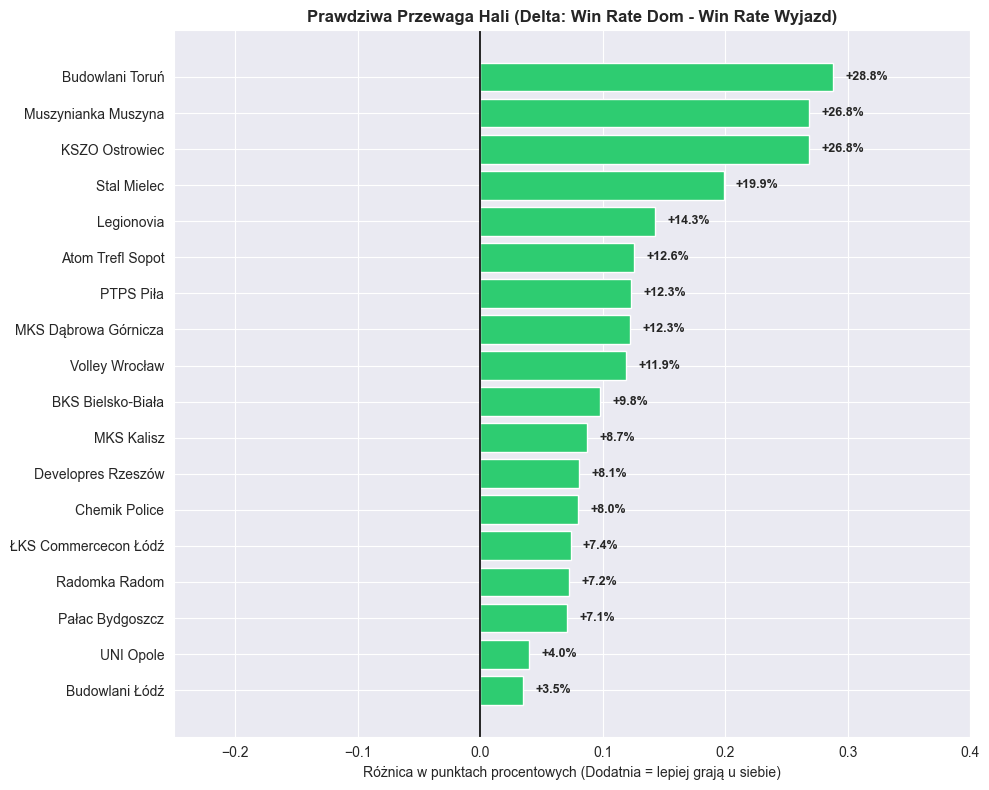

In [92]:
# === PRAWDZIWA PRZEWAGA GOSPODARZA (Oczyszczona z ogólnej siły drużyny) ===

teams = sorted(set(df["team_A"]).union(set(df["team_B"])))
ha_records = []

for team in teams:
    # Statystyki domowe (team gra jako A)
    home_matches = df[df["team_A"] == team]
    home_games = len(home_matches)
    home_wins = home_matches["win_A"].sum()

    # Statystyki wyjazdowe (team gra jako B - wygrywa gdy win_A == 0)
    away_matches = df[df["team_B"] == team]
    away_games = len(away_matches)
    away_wins = (away_matches["win_A"] == 0).sum()

    total_games = home_games + away_games
    total_wins = home_wins + away_wins

    if total_games > 0 and total_wins > 0: # Odrzucamy drużyny bez zwycięstw
        home_win_rate = home_wins / home_games if home_games > 0 else 0
        away_win_rate = away_wins / away_games if away_games > 0 else 0

        ha_records.append({
            "Drużyna": team,
            "Mecze": total_games,
            "Wygrane (Suma)": total_wins,
            "Win Rate (Dom)": home_win_rate,
            "Win Rate (Wyjazd)": away_win_rate,
            "Delta (Dom - Wyjazd)": home_win_rate - away_win_rate,
            "Udział wygranych domowych": home_wins / total_wins
        })

df_ha = pd.DataFrame(ha_records)

# Filtr: Bierzemy pod uwagę tylko drużyny, które wygrały w lidze łącznie minimum 20 meczów
# (żeby uniknąć szumu statystycznego, np. drużyny, która wygrała 1 mecz u siebie i 0 na wyjeździe)
df_ha = df_ha[df_ha["Wygrane (Suma)"] >= 20].copy()

# Sortujemy po prawdziwej przewadze hali (Delta)
df_ha = df_ha.sort_values("Delta (Dom - Wyjazd)", ascending=True)

# Wyświetlamy tabelę z wynikami
print("=== Prawdziwa Przewaga Hali (Top i Flop) ===")
print(df_ha.sort_values("Delta (Dom - Wyjazd)", ascending=False).head(10).round(3).to_string())

# --- GENEROWANIE WYKRESU ---
plt.figure(figsize=(10, 8))
colors = ['#2ECC71' if val > 0 else '#E74C3C' for val in df_ha["Delta (Dom - Wyjazd)"]]

bars = plt.barh(df_ha["Drużyna"], df_ha["Delta (Dom - Wyjazd)"], color=colors, edgecolor="white")
plt.axvline(x=0, color='black', linewidth=1.2)
plt.title("Prawdziwa Przewaga Hali (Delta: Win Rate Dom - Win Rate Wyjazd)", fontweight="bold")
plt.xlabel("Różnica w punktach procentowych (Dodatnia = lepiej grają u siebie)")

# Dodanie wartości na słupkach
for bar, val in zip(bars, df_ha["Delta (Dom - Wyjazd)"]):
    x_pos = bar.get_width()
    ha = 'left' if x_pos > 0 else 'right'
    offset = 0.01 if x_pos > 0 else -0.01
    plt.text(x_pos + offset, bar.get_y() + bar.get_height()/2, f"{val:+.1%}",
             va='center', ha=ha, fontsize=9, fontweight='bold')

plt.xlim(-0.25, 0.4) # Dostosuj oś X w razie potrzeby
plt.tight_layout()
plt.savefig(plot_path("eda", "true_home_advantage.png"), dpi=150, bbox_inches="tight")
plt.show()


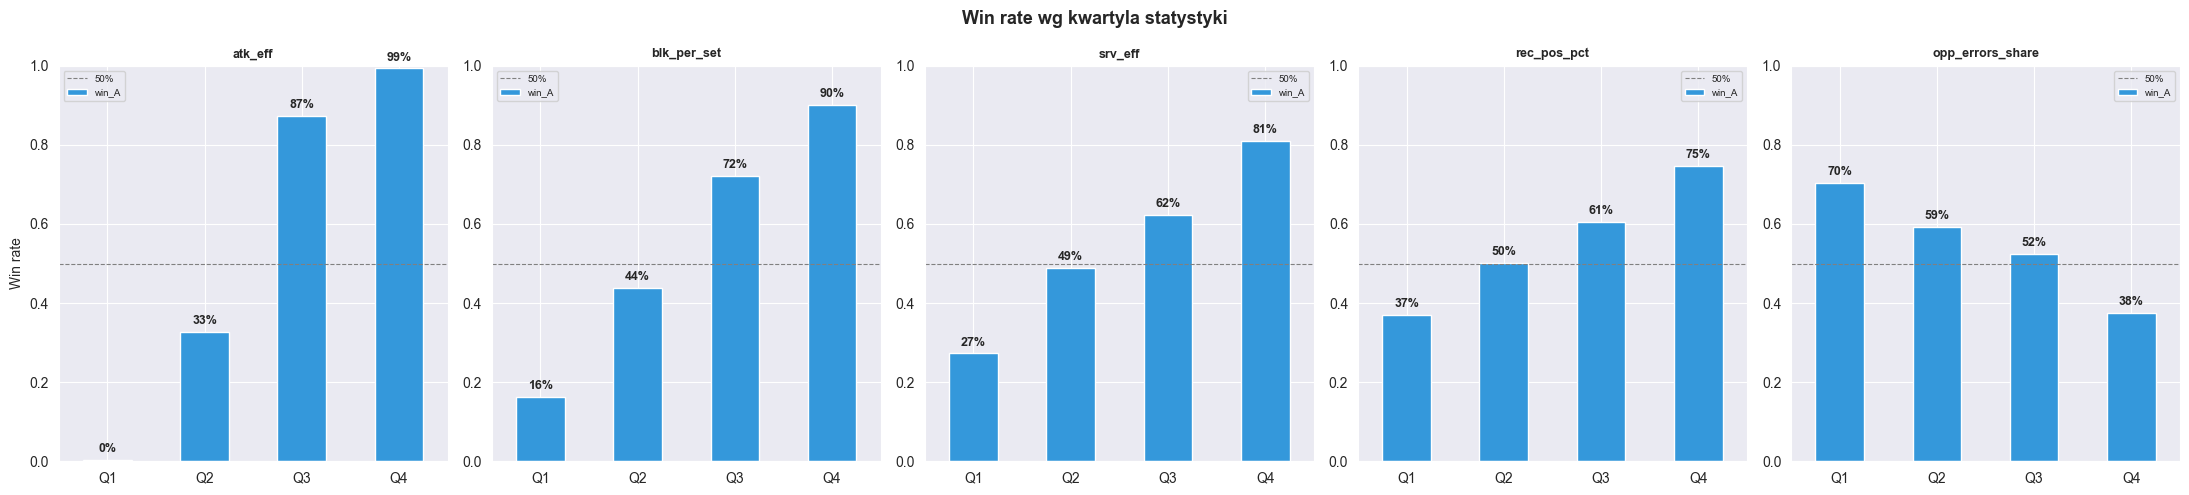

In [93]:
# === Win rate wedlug kwartyla statystyki ===
feats_q = ["diff_atk_eff", "diff_blk_per_set", "diff_srv_eff", "diff_rec_pos_pct", "diff_opp_errors_share"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, feat in zip(axes, feats_q):
    df[f"{feat}_q"] = pd.qcut(df[feat], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    wr = df.groupby(f"{feat}_q", observed=True)["win_A"].mean()
    wr.plot.bar(ax=ax, color="#3498DB", edgecolor="white")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="50%")
    ax.set_title(feat.replace("diff_", ""), fontsize=9, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("Win rate" if feat == feats_q[0] else "")
    ax.tick_params(axis="x", rotation=0)
    for bar, val in zip(ax.patches, wr.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)

plt.suptitle("Win rate wg kwartyla statystyki", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(plot_path("eda", "winrate_kwartyle.png"), dpi=150, bbox_inches="tight")
plt.show()

# Czyscimy pomocnicze kolumny
for feat in feats_q:
    df.drop(columns=[f"{feat}_q"], inplace=True, errors="ignore")


## 4) Selekcja cech

Najpierw usuwamy silnie skorelowane cechy, żeby uniknąć multikolinearności. Potem na wybranych robimy EDA.

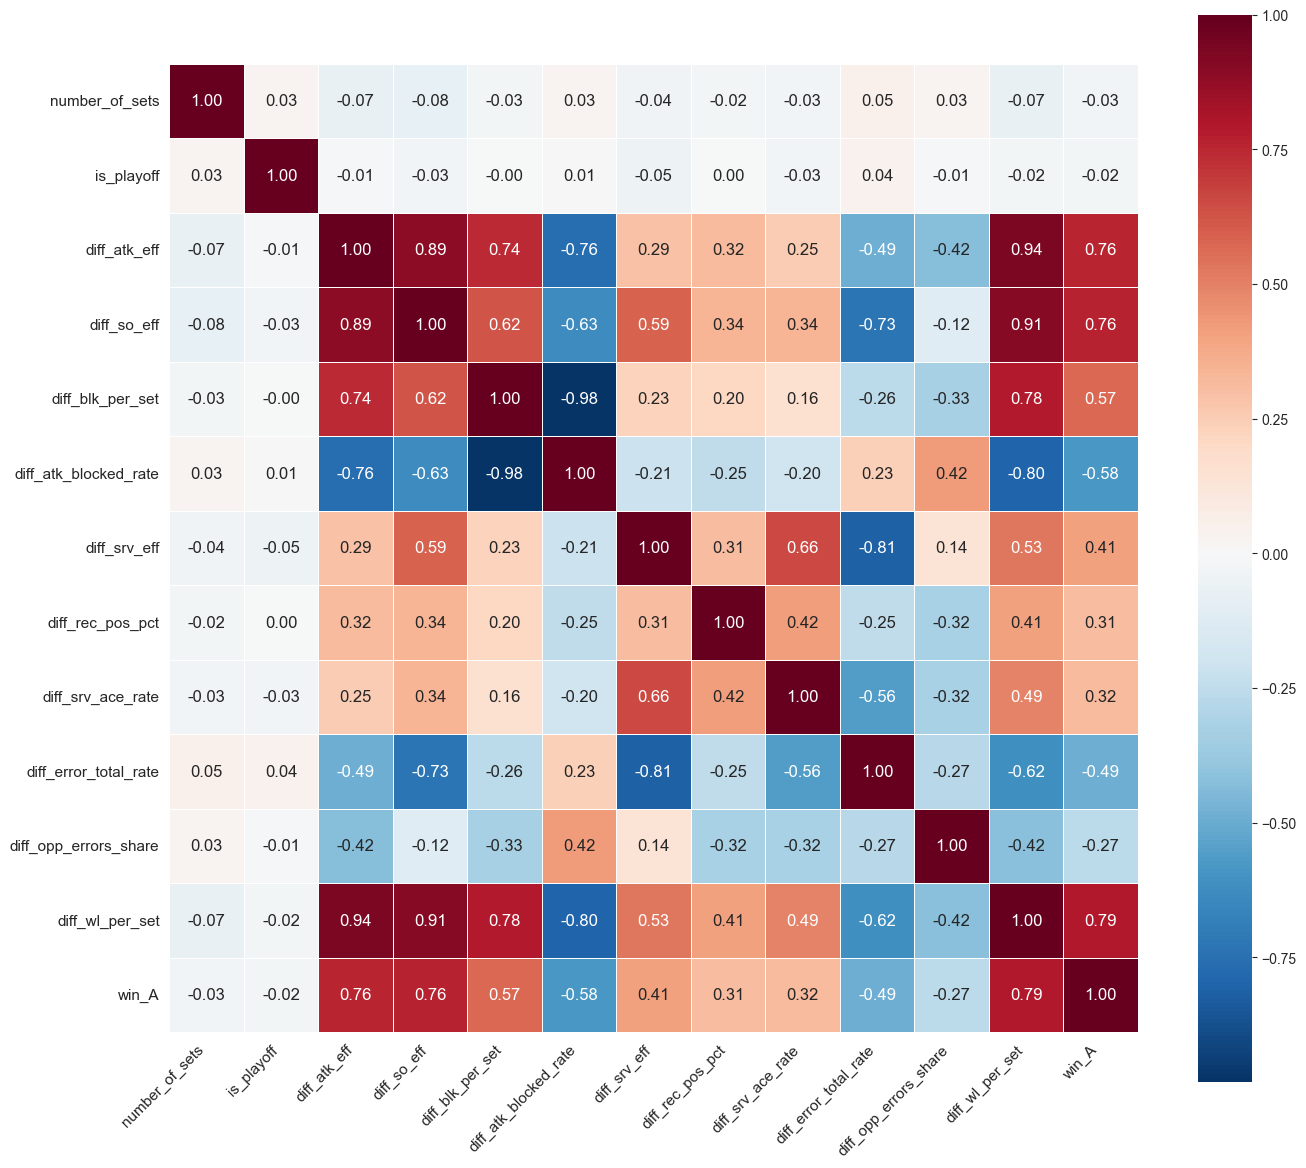

In [94]:
corr_cols = FEATURES_ALL + [TARGET]
corr = df[corr_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(    corr,    cmap="RdBu_r",    center=0,    annot=True,    annot_kws={"size": 12},    fmt=".2f",    linewidths=0.5,    square=True,)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig(plot_path("eda", "Rys_macierz_korelacji.png"), dpi=150, bbox_inches="tight")
plt.show()


In [95]:
target_corr = (
    df[FEATURES_ALL + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .to_frame(name="Korelacja")
)
target_corr["|Korelacja|"] = target_corr["Korelacja"].abs()
target_corr = target_corr.sort_values("|Korelacja|", ascending=False).reset_index()
target_corr = target_corr.rename(columns={"index": "Cecha"})

print(target_corr[["Cecha", "Korelacja"]].round(4).to_string())


                    Cecha  Korelacja
0         diff_wl_per_set     0.7950
1             diff_so_eff     0.7614
2            diff_atk_eff     0.7562
3   diff_atk_blocked_rate    -0.5804
4        diff_blk_per_set     0.5737
5   diff_error_total_rate    -0.4892
6            diff_srv_eff     0.4087
7       diff_srv_ace_rate     0.3160
8        diff_rec_pos_pct     0.3083
9   diff_opp_errors_share    -0.2685
10         number_of_sets    -0.0292
11             is_playoff    -0.0221


In [96]:
corr_pred = df[FEATURES_ALL].corr()
pairs = []
for i, col1 in enumerate(corr_pred.columns):
    for j, col2 in enumerate(corr_pred.columns):
        if i < j:
            val = corr_pred.loc[col1, col2]
            pairs.append((col1, col2, val))
pairs_df = pd.DataFrame(pairs, columns=["Cecha 1", "Cecha 2", "r"])
pairs_df["|r|"] = pairs_df["r"].abs()
pairs_df = pairs_df.sort_values("|r|", ascending=False)
print(pairs_df[pairs_df["|r|"] > 0.70].round(4).to_string())



                  Cecha 1                Cecha 2       r     |r|
38       diff_blk_per_set  diff_atk_blocked_rate -0.9806  0.9806
29           diff_atk_eff        diff_wl_per_set  0.9361  0.9361
37            diff_so_eff        diff_wl_per_set  0.9058  0.9058
21           diff_atk_eff            diff_so_eff  0.8893  0.8893
53           diff_srv_eff  diff_error_total_rate -0.8110  0.8110
50  diff_atk_blocked_rate        diff_wl_per_set -0.8014  0.8014
44       diff_blk_per_set        diff_wl_per_set  0.7846  0.7846
23           diff_atk_eff  diff_atk_blocked_rate -0.7595  0.7595
22           diff_atk_eff       diff_blk_per_set  0.7401  0.7401
35            diff_so_eff  diff_error_total_rate -0.7288  0.7288


### 4.1. Wnioski z analizy korelacji (Redukcja wymiarowości)

Z powyższej analizy par o wysokiej korelacji (|r| > 0.70) płyną jasne wnioski statystyczne, które pokrywają się z logiką gry w siatkówkę:
1. **Atak a Side-out:** Zmienna `diff_so_eff` (skuteczność wyjścia z przyjęcia) jest drastycznie skorelowana z `diff_atk_eff` (efektywnością ataku). Wynika to z faktu, że większość akcji side-out kończy się atakiem. Pozostawienie obu zmiennych doprowadziłoby do współliniowości. Wybieramy `diff_atk_eff` jako miarę bardziej uniwersalną (obejmuje też kontrataki).
2. **Kaskada błędów:** Zmienne takie jak `diff_error_total_rate` są sumą innych błędów (w ataku, na zagrywce). Nie możemy w jednym modelu umieścić szczegółowych wskaźników efektywności (które już zawierają w sobie kary za błędy) oraz ogólnego wskaźnika błędów.
3. **Punkty a wskaźniki per set:** Aby zniwelować różnice między krótkimi (3 sety) a długimi (5 setów) meczami, opieramy się na wartościach uśrednionych (`per_set`) lub procentowych (`rate`, `eff`), odrzucając statystyki absolutne (jak łączna liczba bloków).

### 4.2. Definicja Zestawów Cech (Feature Sets)
Opierając się na powyższej filtracji statystycznej oraz wiedzy domenowej o siatkówce, zamiast szukać jednego "idealnego" modelu, celowo definiujemy **trzy różne ujęcia analityczne**. Pozwoli to sprawdzić stabilność wniosków i zbadać grę z różnych perspektyw:* **Model 1 (Główny):** Nasz model główny. Reprezentuje "siatkarskie DNA". Zawiera po jednym, najlepszym wskaźniku z każdego elementu rzemiosła (Atak, Blok, Serwis, Przyjęcie, darmowe punkty z błędów rywala). Zbudowany tak, by minimalizować VIF.* **Model 2 (Dyscyplina i Presja):** Skupia się na "ciemnej stronie gry". Wyklucza czystą jakość ataku na rzecz miar takich jak błędy własne (`error_total_rate`) i bycie zatrzymanym przez blok rywala (`atk_blocked_rate`).* **Model 3 (Full - Baseline):** Model kontrolny, do którego "wrzucono" wszystkie 12 statystyk. Służy wyłącznie do celów diagnostycznych, by matematycznie udowodnić (poprzez wysoki VIF), że nadmiar danych szkodzi interpretacji. Zmienne kontekstowe (`is_playoff`, `number_of_sets`) dodawane są do każdego modelu jako zmienne kontrolne.

In [97]:
SET1_FEATURES = [
    "diff_atk_eff",
    "diff_blk_per_set",
    "diff_srv_eff",
    "diff_rec_pos_pct",
    "diff_opp_errors_share",
    "number_of_sets",
    "is_playoff",
]


SET2_FEATURES = [
    "diff_atk_blocked_rate",
    "diff_error_total_rate",
    "diff_rec_pos_pct",
    "diff_srv_ace_rate",
    "number_of_sets",
    "is_playoff",
]

SET3_FEATURES = [
    "number_of_sets",
    "is_playoff",
    "diff_atk_eff",
    "diff_so_eff",
    "diff_blk_per_set",
    "diff_atk_blocked_rate",
    "diff_srv_eff",
    "diff_rec_pos_pct",
    "diff_srv_ace_rate",
    "diff_error_total_rate",
    "diff_opp_errors_share",
    "diff_wl_per_set",
]

feature_sets_table = pd.DataFrame(
    [
        {"Model": "Model 1 – Główny", "Liczba cech": len(SET1_FEATURES), "Cechy": ", ".join(SET1_FEATURES)},
        {"Model": "Model 2 – Dyscyplina", "Liczba cech": len(SET2_FEATURES), "Cechy": ", ".join(SET2_FEATURES)},
        {"Model": "Model 3 – Full", "Liczba cech": len(SET3_FEATURES), "Cechy": ", ".join(SET3_FEATURES)},
    ]
)

print(feature_sets_table.to_string())


                  Model  Liczba cech                                                                                                                                                                                                             Cechy
0      Model 1 – Główny            7                                                                                                 diff_atk_eff, diff_blk_per_set, diff_srv_eff, diff_rec_pos_pct, diff_opp_errors_share, number_of_sets, is_playoff
1  Model 2 – Dyscyplina            6                                                                                                     diff_atk_blocked_rate, diff_error_total_rate, diff_rec_pos_pct, diff_srv_ace_rate, number_of_sets, is_playoff
2        Model 3 – Full           12  number_of_sets, is_playoff, diff_atk_eff, diff_so_eff, diff_blk_per_set, diff_atk_blocked_rate, diff_srv_eff, diff_rec_pos_pct, diff_srv_ace_rate, diff_error_total_rate, diff_opp_errors_share, diff_wl_per_set


## 5) Regresja logistyczna i porównanie modeli

W tej części porównujemy trzy zestawy cech. Najpierw dopasowujemy modele
`Logit`, potem zestawiamy współczynniki i na końcu sprawdzamy prostą
walidację `train/test`.


In [98]:
import statsmodels.api as sm

models_def = [
    ("Model 1 – Główny", SET1_FEATURES),
    ("Model 2 – Dyscyplina", SET2_FEATURES),
    ("Model 3 – Full", SET3_FEATURES),
]

all_feats_logit = []
for name, feats in models_def:
    for f in feats:
        if f not in all_feats_logit:
            all_feats_logit.append(f)

results_store = {}
pseudo_r2 = {}
nobs_store = {}
fit_rows = []

for name, feats in models_def:
    X_log, y_log = prepare_xy(df, feats)
    X_log_const = sm.add_constant(X_log)
    result = sm.Logit(y_log, X_log_const).fit(disp=False, maxiter=100)

    results_store[name] = result
    pseudo_r2[name] = result.prsquared
    nobs_store[name] = int(result.nobs)
    fit_rows.append(
        {
            "Model": name,
            "Pseudo R2": result.prsquared,
            "Log-Likelihood": result.llf,
            "Liczba obserwacji": int(result.nobs),
        }
    )

print(pd.DataFrame(fit_rows).round(4).to_string())


                  Model  Pseudo R2  Log-Likelihood  Liczba obserwacji
0      Model 1 – Główny     0.7383       -319.9490               1776
1  Model 2 – Dyscyplina     0.4914       -621.7618               1776
2        Model 3 – Full     0.7958       -249.5864               1776


In [99]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import RobustScaler

trained_sk_models = {}
scalers_store = {}
split_store = {}

# === Krok 1: Trenujemy modele na 80/20 (potrzebne do diagnostyki, PDP, błędów) ===
for name, feats in models_def:
    X_eval, y_eval = prepare_xy(df, feats)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
    )

    scaler = RobustScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    lr = LogisticRegression(C=1e15, max_iter=2000, random_state=42)
    lr.fit(X_tr_s, y_tr)

    scalers_store[name] = scaler
    trained_sk_models[name] = lr
    split_store[name] = {
        "X_tr": X_tr.copy(),
        "X_te": X_te.copy(),
        "y_tr": y_tr.copy(),
        "y_te": y_te.copy(),
        "X_tr_s": X_tr_s,
        "X_te_s": X_te_s,
    }

# === Krok 2: Walidacja LOSO — poprawna czasowo, główne metryki ===
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

validation_rows = []
for name, feats in models_def:
    X_loso, y_loso = prepare_xy(df, feats)
    groups_loso = df.loc[X_loso.index, "season"].reset_index(drop=True)
    X_loso = X_loso.reset_index(drop=True)
    y_loso = y_loso.reset_index(drop=True)

    logo = LeaveOneGroupOut()
    auc_scores = []
    acc_scores = []

    for train_idx, test_idx in logo.split(X_loso, y_loso, groups=groups_loso):
        X_tr_fold = X_loso.iloc[train_idx]
        X_te_fold = X_loso.iloc[test_idx]
        y_tr_fold = y_loso.iloc[train_idx]
        y_te_fold = y_loso.iloc[test_idx]

        scaler_fold = RobustScaler()
        X_tr_fold_s = scaler_fold.fit_transform(X_tr_fold)
        X_te_fold_s = scaler_fold.transform(X_te_fold)

        lr_fold = LogisticRegression(C=1e15, max_iter=2000, random_state=42)
        lr_fold.fit(X_tr_fold_s, y_tr_fold)

        y_prob_fold = lr_fold.predict_proba(X_te_fold_s)[:, 1]
        auc_scores.append(roc_auc_score(y_te_fold, y_prob_fold))
        acc_scores.append(lr_fold.score(X_te_fold_s, y_te_fold))

    validation_rows.append({
        "Model": name,
        "Accuracy LOSO (mean)": round(np.mean(acc_scores), 4),
        "Accuracy LOSO (std)": round(np.std(acc_scores), 4),
        "AUC LOSO (mean)": round(np.mean(auc_scores), 4),
        "AUC LOSO (std)": round(np.std(auc_scores), 4),
        "Pseudo R2 (pełne dane)": pseudo_r2[name],
        "N": nobs_store[name],
    })

validation_df = pd.DataFrame(validation_rows).sort_values("Pseudo R2 (pełne dane)", ascending=False)
print(validation_df.round(4).to_string())

best_descriptive_model = validation_df.iloc[0]["Model"]
print(f"Najwyższe Pseudo R-squared (model opisowy): {best_descriptive_model}")
print(f"Główna metryka walidacyjna: LOSO (Leave-One-Season-Out) — poprawna czasowo.")

# === Krok 3: Zmienne potrzebne w dalszych komórkach (diagnostyka na 80/20) ===
X_tr1 = split_store["Model 1 – Główny"]["X_tr"]
X_te1 = split_store["Model 1 – Główny"]["X_te"]
y_tr1 = split_store["Model 1 – Główny"]["y_tr"]
y_te1 = split_store["Model 1 – Główny"]["y_te"]
X_tr1_s = split_store["Model 1 – Główny"]["X_tr_s"]
X_te1_s = split_store["Model 1 – Główny"]["X_te_s"]
scaler1 = scalers_store["Model 1 – Główny"]
logit_mod1_clean = sm.Logit(y_tr1, sm.add_constant(X_tr1)).fit(disp=0)

# === Krok 4: Model opisowy na pełnych danych (dla tabeli OR i efektów krańcowych) ===
X_full, y_full = prepare_xy(df, SET1_FEATURES)
logit_mod1_full = sm.Logit(y_full, sm.add_constant(X_full)).fit(disp=0)


                  Model  Accuracy LOSO (mean)  Accuracy LOSO (std)  AUC LOSO (mean)  AUC LOSO (std)  Pseudo R2 (pełne dane)     N
2        Model 3 – Full                0.9365               0.0212           0.9865          0.0058                  0.7958  1776
0      Model 1 – Główny                0.9280               0.0236           0.9789          0.0108                  0.7383  1776
1  Model 2 – Dyscyplina                0.8374               0.0253           0.9221          0.0177                  0.4914  1776
Najwyższe Pseudo R-squared (model opisowy): Model 3 – Full
Główna metryka walidacyjna: LOSO (Leave-One-Season-Out) — poprawna czasowo.


In [100]:
# === BRIER SCORE dla wszystkich trzech modeli (na zbiorze testowym 20%) ===
from sklearn.metrics import brier_score_loss


for name in ["Model 1 – Główny", "Model 2 – Dyscyplina", "Model 3 – Full"]:
    model = trained_sk_models[name]
    X_te = split_store[name]["X_te_s"]
    y_te = split_store[name]["y_te"]
    y_prob = model.predict_proba(X_te)[:, 1]
    bs = brier_score_loss(y_te, y_prob)
    print(f"  {name:30s}  Brier = {bs:.4f}")


  Model 1 – Główny                Brier = 0.0498
  Model 2 – Dyscyplina            Brier = 0.1138
  Model 3 – Full                  Brier = 0.0450


In [101]:
# === TABELA WSPÓŁCZYNNIKÓW I ILORAZÓW SZANS — Model 1 (Główny) ===
import statsmodels.api as sm
import numpy as np
import pandas as pd

# 1. Skalujemy TYLKO zmienne procentowe/ułamkowe, by OR oznaczało "wzrost o 1 p.p."
scale_feats = ["diff_atk_eff", "diff_srv_eff", "diff_opp_errors_share"]

# Pracujemy na pełnych danych — model opisowy in-sample. LOSO służy do walidacji zewnętrznej.
X_full_pct = X_full.copy()
X_full_pct[scale_feats] = X_full_pct[scale_feats] * 100

# 2. Fitujemy model na nowej, znormalizowanej skali
logit_mod1_full = sm.Logit(y_full, sm.add_constant(X_full_pct)).fit(disp=0)

# 3. Budujemy elegancką tabelę
coef_rows = []
for feature in SET1_FEATURES:
    if feature not in logit_mod1_full.params.index:
        continue

    coef = logit_mod1_full.params[feature]
    se   = logit_mod1_full.bse[feature]
    pval = logit_mod1_full.pvalues[feature]
    OR   = np.exp(coef)
    ci_lo, ci_hi = np.exp(logit_mod1_full.conf_int().loc[feature])

    # Przypisywanie gwiazdek istotności
    if pval < 0.001:   stars = "***"
    elif pval < 0.01:  stars = "**"
    elif pval < 0.05:  stars = "*"
    else:              stars = ""

    coef_rows.append({
        "Cecha":      feature,
        "Coef":       round(coef, 4),
        "SE":         round(se, 4),
        "p-value":    round(pval, 4),
        "Istotność":  stars,
        "Odds Ratio": round(OR, 4),
        "OR 95% low": round(ci_lo, 4),
        "OR 95% hi":  round(ci_hi, 4),
    })

coef_df = pd.DataFrame(coef_rows)

# 4. Wyświetlanie wyników
print("=" * 95)
print("  TABELA WSPÓŁCZYNNIKÓW I ILORAZÓW SZANS (Model 1 — model opisowy na pełnych danych, in-sample)")
print("=" * 95)
# Wyświetlamy posortowane po wielkości efektu (Odds Ratio)
print(coef_df.sort_values("Odds Ratio", ascending=False).reset_index(drop=True).to_string())

print("Istotność: * p<0.05  ** p<0.01  *** p<0.001")
print("\n📌 NOTA INTERPRETACYJNA DO ODDS RATIO (OR):")
print(" • Dla zmiennych procentowych (atak, zagrywka, błędy rywala):")
print("   OR oznacza mnożnik szansy na wygraną przy wzroście przewagi o 1 punkt procentowy (1 p.p.).")
print(" • Dla zmiennej 'diff_blk_per_set':")
print("   OR oznacza mnożnik szansy na wygraną przy wzroście przewagi o 1 blok na set.")
print(" • Dla zmiennej 'number_of_sets':")
print("   OR oznacza mnożnik szansy na wygraną przy rozegraniu każdego kolejnego seta.")


  TABELA WSPÓŁCZYNNIKÓW I ILORAZÓW SZANS (Model 1 — model opisowy na pełnych danych, in-sample)
                   Cecha    Coef      SE  p-value Istotność  Odds Ratio  OR 95% low  OR 95% hi
0           diff_atk_eff  0.3710  0.0231   0.0000       ***      1.4491      1.3850     1.5162
1           diff_srv_eff  0.2571  0.0239   0.0000       ***      1.2932      1.2341     1.3551
2       diff_rec_pos_pct  0.0140  0.0111   0.2081                1.0141      0.9922     1.0364
3         number_of_sets  0.0059  0.1593   0.9703                1.0060      0.7362     1.3746
4             is_playoff -0.0127  0.2703   0.9626                0.9874      0.5814     1.6770
5  diff_opp_errors_share -0.0320  0.0159   0.0448         *      0.9685      0.9388     0.9993
6       diff_blk_per_set -0.1715  0.1009   0.0891                0.8424      0.6913     1.0266
Istotność: * p<0.05  ** p<0.01  *** p<0.001

📌 NOTA INTERPRETACYJNA DO ODDS RATIO (OR):
 • Dla zmiennych procentowych (atak, zagrywka, błędy ryw

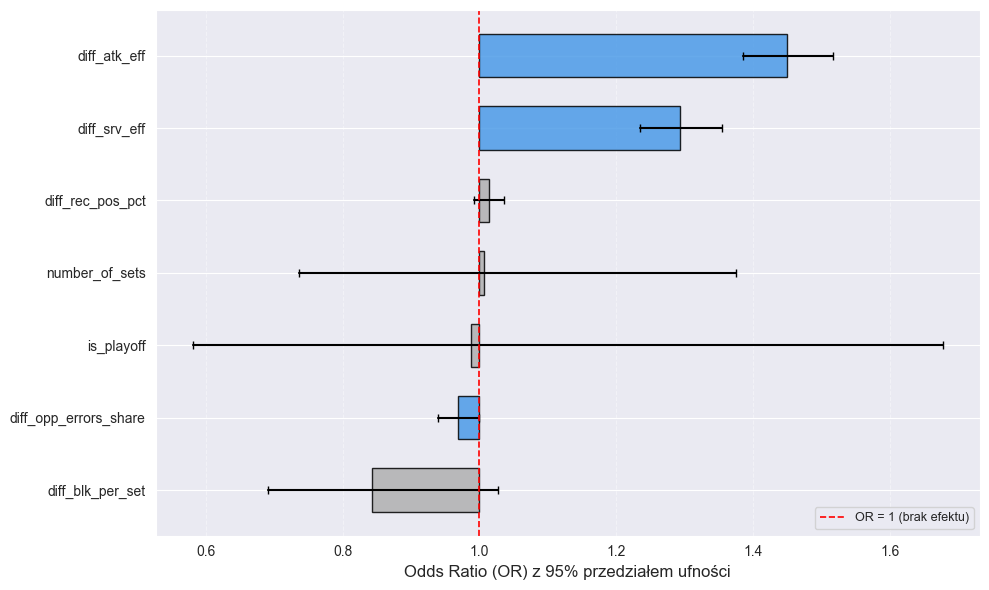

In [102]:
# === WYKRES: Forest plot dla Odds Ratio z 95% CI (Model 1) ===
plt.figure(figsize=(10, 6))

# Sortujemy OR malejąco dla czytelności
plot_df = coef_df.sort_values("Odds Ratio", ascending=True).copy()

# Kolory: istotne (p<0.05) = niebieski (wygrana), nieistotne = szary
WIN_COLOR  = "#4C9BE8"  # niebieski — zgodny z paletą boxplotów
LOSS_COLOR = "#B0B0B0"  # szary — nieistotne
colors = [WIN_COLOR if p < 0.05 else LOSS_COLOR for p in plot_df["p-value"]]

y_pos = range(len(plot_df))
plt.barh(y_pos, plot_df["Odds Ratio"].values - 1,  # odejmujemy 1, by OR=1 wypadalo na 0
         left=1, height=0.6, color=colors, edgecolor="black", alpha=0.85)

# Przedziały ufności
for i, (_, row) in enumerate(plot_df.iterrows()):
    plt.plot([row["OR 95% low"], row["OR 95% hi"]], [i, i],
             color="black", linewidth=1.5, marker="|", markersize=6)

plt.axvline(x=1, color="red", linestyle="--", linewidth=1.2, label="OR = 1 (brak efektu)")
plt.yticks(list(y_pos), plot_df["Cecha"].values)
plt.xlabel("Odds Ratio (OR) z 95% przedziałem ufności", fontsize=12)
# Tytuł usunięty — podpis "Rys. 5. ..." idzie pod rysunkiem w pracy
plt.legend(loc="lower right", fontsize=9)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(plot_path("modeling", "Rys5_forest_plot_OR_model1.png"), dpi=150, bbox_inches="tight")
plt.show()


## Walidacja LOSO i Permutation Importance — Model 1 (Random Forest)

Ta komórka wykonuje **dodatkową walidację i diagnostykę** dla Modelu 1 przy użyciu Random Forest (model nieliniowy, uzupełnienie dla regresji logistycznej):

**1. Walidacja LOSO (Leave-One-Season-Out)**
- Trenuje Random Forest na 10 sezonach, testuje na 1 pozostałym (iteracja po wszystkich sezonach)
- Sprawdza, czy model nie przeszacowuje na tle czasowym
- Wyświetla accuracy dla każdego sezonu oraz średnią i odchylenie standardowe

**2. Permutation Feature Importance**
- Mierzy, o ile spada accuracy modelu po losowym przetasowaniu wartości danej cechy na zbiorze testowym (20% danych)
- Większy spadek = ważniejsza cecha
- Powtarza 50 razy dla stabilności estymacji
- Wyniki prezentowane są na wykresie słupkowym z 95% przedziałami ufności

**Cel:** Potwierdzenie stabilności modelu w czasie oraz identyfikacja, które cechy mają największy rzeczywisty wpływ na predykcje.

       season  accuracy
0   2015/2016    0.8834
1   2016/2017    0.9538
2   2017/2018    0.9059
3   2018/2019    0.9045
4   2019/2020    0.9070
5   2020/2021    0.9130
6   2021/2022    0.9299
7   2022/2023    0.9118
8   2023/2024    0.9304
9   2024/2025    0.8917
10  2025/2026    0.9068
           Wskaźnik  Wartość
0  Średnia accuracy   0.9126
1    Odchylenie std   0.0194
                   Cecha  Importance_Mean  Importance_Std
0           diff_atk_eff           0.3880          0.0222
2           diff_srv_eff           0.0409          0.0116
3       diff_rec_pos_pct           0.0042          0.0054
5         number_of_sets           0.0028          0.0055
6             is_playoff           0.0024          0.0010
4  diff_opp_errors_share           0.0003          0.0034
1       diff_blk_per_set          -0.0016          0.0049


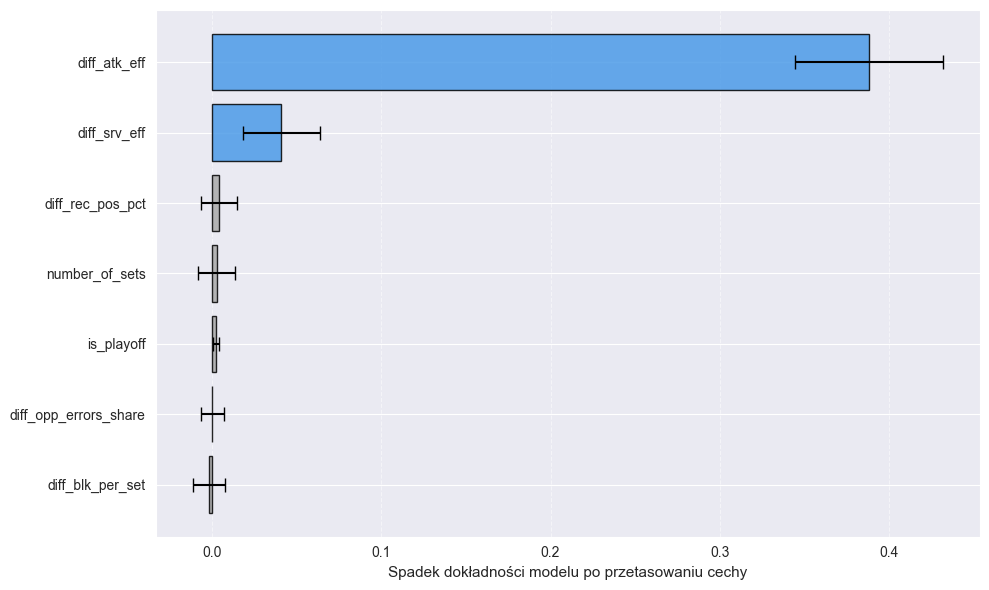

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut

features_mod1 = SET1_FEATURES.copy()
X_rf, y_rf = prepare_xy(df, features_mod1)
groups_rf = df.loc[X_rf.index, "season"].reset_index(drop=True)
X_rf = X_rf.reset_index(drop=True)
y_rf = y_rf.reset_index(drop=True)

logo = LeaveOneGroupOut()
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)

season_scores = []
for train_idx, test_idx in logo.split(X_rf, y_rf, groups=groups_rf):
    X_tr_fold = X_rf.iloc[train_idx]
    X_te_fold = X_rf.iloc[test_idx]
    y_tr_fold = y_rf.iloc[train_idx]
    y_te_fold = y_rf.iloc[test_idx]
    rf.fit(X_tr_fold, y_tr_fold)
    season_scores.append(
        {
            "season": groups_rf.iloc[test_idx].iloc[0],
            "accuracy": rf.score(X_te_fold, y_te_fold),
        }
    )

season_scores_df = pd.DataFrame(season_scores)
print(season_scores_df.round(4).to_string())
summary_rf = pd.DataFrame(
    {
        "Wskaźnik": ["Średnia accuracy", "Odchylenie std"],
        "Wartość": [
            round(season_scores_df["accuracy"].mean(), 4),
            round(season_scores_df["accuracy"].std(), 4),
        ],
    }
)
print(summary_rf.to_string())

# Model dla Permutation Importance — trenowany na 80% danych, ewaluowany na 20%
# (out-of-sample: model nie widzial danych testowych; PDP uzywa osobnego modelu na pelnych danych)
rf_perm = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_perm.fit(X_tr1, y_tr1)

perm_result = permutation_importance(
    rf_perm, X_te1, y_te1, n_repeats=50, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame(
    {
        "Cecha": SET1_FEATURES,
        "Importance_Mean": perm_result.importances_mean,
        "Importance_Std": perm_result.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

print(perm_df.round(4).to_string())

plt.figure(figsize=(10, 6))

WIN_COLOR = "#4C9BE8"
GRAY = "#AAAAAA"
significant = ["diff_atk_eff", "diff_srv_eff"]
colors = [WIN_COLOR if feat in significant else GRAY for feat in perm_df["Cecha"]]

plt.barh(
    perm_df["Cecha"],
    perm_df["Importance_Mean"],
    xerr=1.96 * perm_df["Importance_Std"],
    color=colors,
    edgecolor="black",
    capsize=5,
    alpha=0.85,
)
plt.gca().invert_yaxis()
plt.xlabel("Spadek dokładności modelu po przetasowaniu cechy", fontsize=11)
# Tytuł usunięty — podpis "Rys. 7. ..." idzie pod rysunkiem w pracy
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(plot_path("modeling", "Rys7_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.show()


## Diagnostyka wizualna Modelu 1 na zbiorze testowym

Po walidacji liczbowej (LOSO, Permutation Importance) warto **zobaczyć** jak model radzi sobie na danych, których nie widział podczas treningu (20% wydzielone na początku). Ta komórka generuje trzy wykresy:

**1. Macierz pomyłek (Confusion Matrix)**
- Pokazuje liczbę poprawnych i błędnych klasyfikacji
- Wnioskowanie: czy model częściej myli się w jedną stronę (fałszywie pozytywne vs. fałszywie negatywne)

**2. Krzywa ROC z AUC**
- Mierzy zdolność modelu do rozróżniania klas przy różnych progach decyzyjnych
- AUC = 1 oznacza idealny model, AUC = 0.5 to model losowy

**3. Krzywa kalibracji (Calibration Curve)**
- Sprawdza, czy przewidywane prawdopodobieństwa są dobrze wyskalowane
- Idealnie dopasowany model leży na przekątnej (przewidywane = zaobserwowane)
- Jeżeli krzywa odchyla się od przekątnej, model jest źle skalibrowany (overconfidence lub underconfidence)

**Cel:** Ocena jakości predykcji Modelu 1 z trzech różnych perspektyw – dyskryminacji (ROC), dokładności (CM) i skalowania (kalibracja).

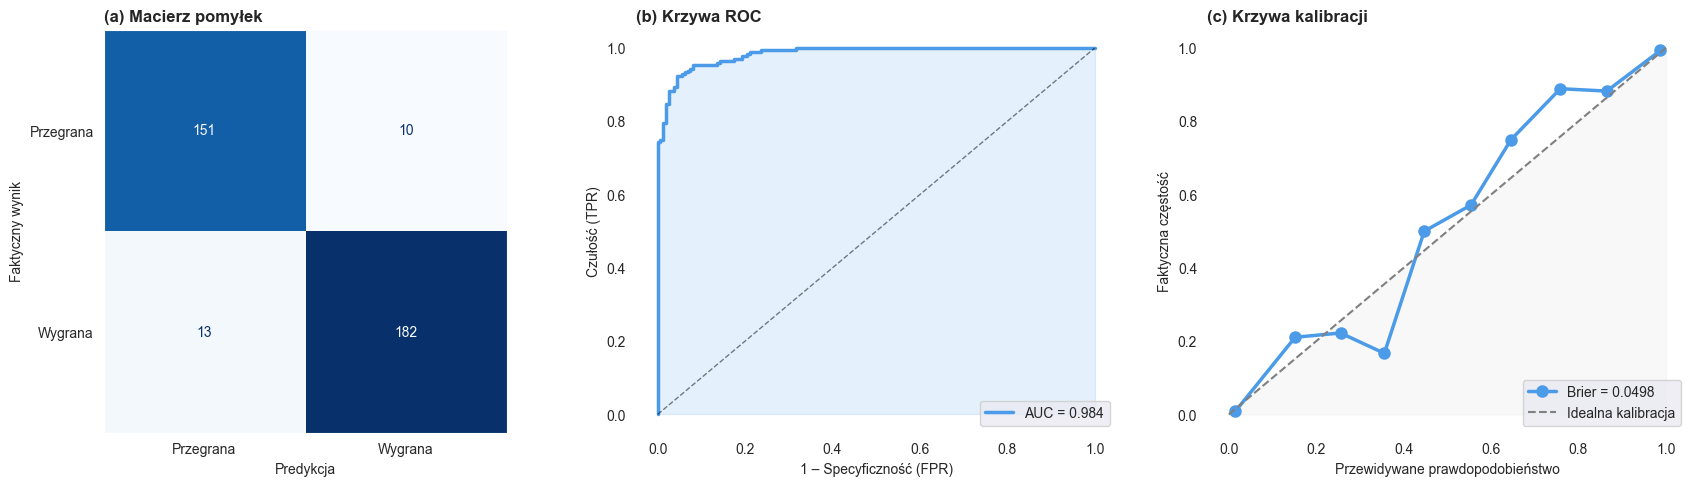

In [104]:
# === DIAGNOSTYKA WIZUALNA MODELU 1 NA ZBIORZE TESTOWYM (ROC, CM, KALIBRACJA) ===

from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc

model1_sk = trained_sk_models["Model 1 – Główny"]
y_prob_sk = model1_sk.predict_proba(X_te1_s)[:, 1]
y_pred_sk = model1_sk.predict(X_te1_s)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Macierz pomyłek
cm = confusion_matrix(y_te1, y_pred_sk)
disp = ConfusionMatrixDisplay(cm, display_labels=["Przegrana", "Wygrana"])
disp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].grid(False)
axes[0].set_title("(a) Macierz pomyłek", fontsize=12, fontweight="bold", loc="left")
axes[0].set_ylabel("Faktyczny wynik")
axes[0].set_xlabel("Predykcja")

# 2. Krzywa ROC
fpr, tpr, _ = roc_curve(y_te1, y_prob_sk)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#4C9BE8", lw=2.5, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.15, color="#4C9BE8")
axes[1].set_xlabel("1 – Specyficzność (FPR)")
axes[1].set_ylabel("Czułość (TPR)")
axes[1].set_title("(b) Krzywa ROC", fontsize=12, fontweight="bold", loc="left")
axes[1].legend(loc="lower right")
axes[1].set_facecolor("white")

# 3. Krzywa Kalibracji
prob_true, prob_pred = calibration_curve(y_te1, y_prob_sk, n_bins=10, strategy="uniform")
brier = np.mean((y_prob_sk - y_te1) ** 2)
axes[2].plot(prob_pred, prob_true, marker="o", lw=2.5, markersize=8, color="#4C9BE8", label=f"Brier = {brier:.4f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray", lw=1.5, label="Idealna kalibracja")
axes[2].fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
axes[2].set_xlabel("Przewidywane prawdopodobieństwo")
axes[2].set_ylabel("Faktyczna częstość")
axes[2].set_title("(c) Krzywa kalibracji", fontsize=12, fontweight="bold", loc="left")
axes[2].legend(loc="lower right")
axes[2].set_facecolor("white")

# fig.suptitle usunięty — podpis "Rys. 4. ..." idzie pod rysunkiem w pracy
plt.tight_layout(pad=3.0)
plt.savefig(plot_path("modeling", "Rys4_diagnostics.png"), dpi=150, bbox_inches="tight")
plt.show()


## 6) Pogłębiona analiza Modelu 1

Model ekspercki traktujemy jako główny punkt odniesienia, dlatego niżej
sprawdzamy jego stabilność względem innych algorytmów, różnych kontekstów
meczu i obserwacji wpływowych.


### 6.1. Porównanie z prostym modelem nieliniowym

Celem nie jest wybranie najlepszego algorytmu za wszelką cenę, tylko
sprawdzenie, czy interpretacje z regresji logistycznej nie załamują się
po przejściu do bardziej elastycznego modelu.


In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score

X_comp, y_comp = prepare_xy(df, SET1_FEATURES)
groups_comp = df.loc[X_comp.index, "season"].reset_index(drop=True)
X_comp = X_comp.reset_index(drop=True)
y_comp = y_comp.reset_index(drop=True)

from sklearn.pipeline import make_pipeline

comp_models = {
    "Logistic Regression": make_pipeline(
        RobustScaler(),
        LogisticRegression(C=1e15, max_iter=2000, random_state=42)
    ),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
}

comparison_rows = []
for name, model in comp_models.items():
    cv_scores = cross_val_score(model, X_comp, y_comp, cv=LeaveOneGroupOut(), groups=groups_comp, scoring="accuracy")
    comparison_rows.append(
        {
            "Model": name,
            "Accuracy LOSO mean": cv_scores.mean(),
            "Accuracy LOSO std": cv_scores.std(),
        }
    )

print(pd.DataFrame(comparison_rows).round(4).to_string())
print("\nPorównanie Logistic Regression vs Random Forest — LOSO (Leave-One-Season-Out).")


                 Model  Accuracy LOSO mean  Accuracy LOSO std
0  Logistic Regression              0.9280             0.0236
1        Random Forest              0.9126             0.0185

Porównanie Logistic Regression vs Random Forest — LOSO (Leave-One-Season-Out).


### 6.2. Waga statystyk w różnych warunkach meczu

Porównujemy współczynniki osobno dla playoffów i sezonu zasadniczego oraz
dla tie-breaków i meczów kończących się w 3-4 setach.


In [106]:
# Skalujemy proporcje tak samo jak w Tabeli 2 — dla spójności i czytelności wykresu
SCALE_FEATS = ["diff_atk_eff", "diff_srv_eff", "diff_opp_errors_share"]

def get_logit_coefs(df_in, feats):
    # Analiza opisowa — modele fitowane na pełnych podzbiorach (in-sample)
    X_sub, y_sub = prepare_xy(df_in, feats)
    # Skalujemy zmienne ułamkowe do pp. (zgodnie z Tabelą 2)
    for f in SCALE_FEATS:
        if f in X_sub.columns:
            X_sub = X_sub.copy()
            X_sub[f] = X_sub[f] * 100
    constant_cols = [c for c in X_sub.columns if X_sub[c].nunique() <= 1]
    if constant_cols:
        X_sub = X_sub.drop(columns=constant_cols)
    return sm.Logit(y_sub, sm.add_constant(X_sub)).fit(disp=0).params


coefs_regular = get_logit_coefs(df[df["is_playoff"] == 0], SET1_FEATURES)
coefs_playoff = get_logit_coefs(df[df["is_playoff"] == 1], SET1_FEATURES)
coefs_normal = get_logit_coefs(df[df["number_of_sets"] < 5], SET1_FEATURES)
coefs_tiebreak = get_logit_coefs(df[df["number_of_sets"] == 5], SET1_FEATURES)


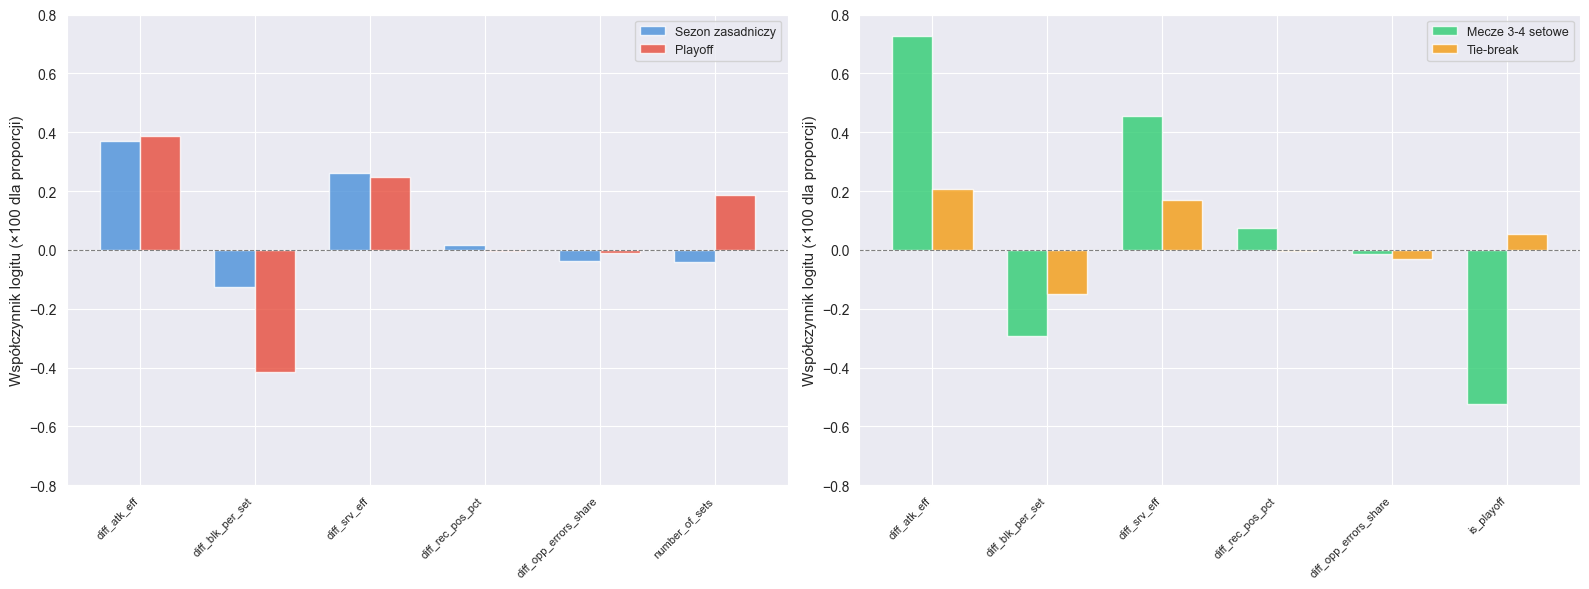

Uwaga: współczynniki dla diff_atk_eff, diff_srv_eff, diff_opp_errors_share są w skali ×100 (zmiana o 1 p.p.).
Pozostałe cechy w jednostkach naturalnych. Wykres pokazuje WZGLĘDNĄ zmianę wag między kontekstami.


In [107]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparisons = [
    ("Sezon zasadniczy vs Playoff", coefs_regular, coefs_playoff, ["#4A90D9", "#E74C3C"]),
    ("Mecze 3-4 setowe vs Tie-break", coefs_normal, coefs_tiebreak, ["#2ECC71", "#F39C12"]),
]

for ax, (title, c1, c2, colors) in zip(axes, comparisons):
    features_plot = [f for f in SET1_FEATURES if f in c1.index and f in c2.index]
    x = np.arange(len(features_plot))
    width = 0.35

    ax.bar(x - width / 2, [c1[f] for f in features_plot], width, label=title.split(" vs ")[0], color=colors[0], alpha=0.8)
    ax.bar(x + width / 2, [c2[f] for f in features_plot], width, label=title.split(" vs ")[1], color=colors[1], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(features_plot, rotation=45, ha="right", fontsize=8)
    ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_ylim(-0.8, 0.8)
    ax.set_ylabel("Współczynnik logitu (×100 dla proporcji)", fontsize=11)
    # Tytuł usunięty — podpis pod rysunkiem w pracy
    ax.legend(fontsize=9)

# fig.suptitle usunięty — podpis pod rysunkiem w pracy
plt.tight_layout()
plt.savefig(plot_path("eda", "wagi_kontekstowe.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Uwaga: współczynniki dla diff_atk_eff, diff_srv_eff, diff_opp_errors_share są w skali ×100 (zmiana o 1 p.p.).")
print("Pozostałe cechy w jednostkach naturalnych. Wykres pokazuje WZGLĘDNĄ zmianę wag między kontekstami.")


In [108]:
def coefficient_shift_table(reference, compared, label):
    rows = []
    for feature in SET1_FEATURES:
        if feature in reference.index and feature in compared.index:
            rows.append(
                {
                    "Cecha": feature,
                    "ref": reference[feature],
                    "cmp": compared[feature],
                    "delta": compared[feature] - reference[feature],
                }
            )
    table = pd.DataFrame(rows)
    print(label)
    print(table.round(4).to_string())


coefficient_shift_table(coefs_regular, coefs_playoff, "Playoff vs sezon zasadniczy")
coefficient_shift_table(coefs_normal, coefs_tiebreak, "Tie-break vs mecze 3-4 setowe")
print("\nUwaga: wspolczynniki dla diff_atk_eff, diff_srv_eff, diff_opp_errors_share sa w skali ×100 (zgodnie z Tabela 2).")


Playoff vs sezon zasadniczy
                   Cecha     ref     cmp   delta
0           diff_atk_eff  0.3702  0.3861  0.0159
1       diff_blk_per_set -0.1255 -0.4138 -0.2883
2           diff_srv_eff  0.2607  0.2485 -0.0121
3       diff_rec_pos_pct  0.0169 -0.0033 -0.0201
4  diff_opp_errors_share -0.0362 -0.0100  0.0262
5         number_of_sets -0.0399  0.1854  0.2253
Tie-break vs mecze 3-4 setowe
                   Cecha     ref     cmp   delta
0           diff_atk_eff  0.7256  0.2078 -0.5178
1       diff_blk_per_set -0.2909 -0.1508  0.1401
2           diff_srv_eff  0.4541  0.1686 -0.2855
3       diff_rec_pos_pct  0.0740 -0.0026 -0.0766
4  diff_opp_errors_share -0.0133 -0.0321 -0.0187
5             is_playoff -0.5235  0.0526  0.5760

Uwaga: wspolczynniki dla diff_atk_eff, diff_srv_eff, diff_opp_errors_share sa w skali ×100 (zgodnie z Tabela 2).


### 6.3. Gdzie model myli się najczęściej

Ta sekcja zbiera błędy klasyfikacji i pokazuje najbardziej nietypowe mecze,
czyli takie, w których model był pewny, a wynik okazał się przeciwny.


In [109]:
# === Analiza bledow na zbiorze testowym (z split_store) ===

model1_sk = trained_sk_models["Model 1 – Główny"]
df_te = X_te1.copy()
df_te["prob"] = model1_sk.predict_proba(X_te1_s)[:, 1]
df_te["pred"] = model1_sk.predict(X_te1_s)
df_te["is_error"] = (df_te["pred"] != y_te1.values).astype(int)
df_te["season"] = df.loc[X_te1.index, "season"].values
df_te["team_A"] = df.loc[X_te1.index, "team_A"].values
df_te["team_B"] = df.loc[X_te1.index, "team_B"].values
df_te["is_playoff"] = df.loc[X_te1.index, "is_playoff"].values
df_te["number_of_sets"] = df.loc[X_te1.index, "number_of_sets"].values
df_te[TARGET] = y_te1.values

error_summary = pd.Series(
    {
        "Ogólny błąd": df_te["is_error"].mean(),
        "Błędy w playoff": df_te.loc[df_te["is_playoff"] == 1, "is_error"].mean(),
        "Błędy w sezonie": df_te.loc[df_te["is_playoff"] == 0, "is_error"].mean(),
        "Błędy w tie-breakach": df_te.loc[df_te["number_of_sets"] == 5, "is_error"].mean(),
        "Błędy w meczach 3-4 setowych": df_te.loc[df_te["number_of_sets"] < 5, "is_error"].mean(),
    }
)
print(error_summary.to_frame("wartosc").round(4).to_string())

anomalies = (
    df_te[df_te["is_error"] == 1]
    .sort_values("prob", ascending=False)
    .head(10)
    .loc[:, ["season", "team_A", "team_B","number_of_sets", "prob", "pred", TARGET]]
    .copy()
)
anomalies["pred"] = anomalies["pred"].map({1: "Wygrana A", 0: "Przegrana A"})
anomalies[TARGET] = anomalies[TARGET].map({1: "Wygrana A", 0: "Przegrana A"})
print(anomalies.to_string())


                              wartosc
Ogólny błąd                    0.0646
Błędy w playoff                0.0667
Błędy w sezonie                0.0643
Błędy w tie-breakach           0.2208
Błędy w meczach 3-4 setowych   0.0215
         season              team_A                team_B  number_of_sets      prob       pred        win_A
802   2019/2020          MKS Kalisz             PTPS Piła               5  0.910970  Wygrana A  Przegrana A
1508  2024/2025  Developres Rzeszów  ŁKS Commercecon Łódź               4  0.899652  Wygrana A  Przegrana A
1151  2021/2022       Radomka Radom            Legionovia               5  0.860918  Wygrana A  Przegrana A
706   2018/2019     Pałac Bydgoszcz     BKS Bielsko-Biała               4  0.757287  Wygrana A  Przegrana A
1617  2025/2026           UNI Opole  ŁKS Commercecon Łódź               4  0.645882  Wygrana A  Przegrana A
1565  2024/2025       Sokół Mogilno             UNI Opole               5  0.643868  Wygrana A  Przegrana A
1192  2022/2023 

### 6.4. Stabilność czasowa i diagnostyka modelu

Sprawdzamy odporność modelu na zmianę sezonu, jakość kalibracji oraz wpływ
zmiennych kontekstowych na interpretację współczynników.

#### Endogeniczność zmiennej `number_of_sets`

Zmienna `number_of_sets` (liczba setów w meczu) może budzić obawy o endogeniczność,
ponieważ mecze tie-breakowe są z definicji dłuższe, a ich przebieg statystyczny może
się różnić od meczów 3–4 setowych. Aby zweryfikować, czy obecność tej zmiennej nie
zaburza estymacji pozostałych predyktorów, oszacowano model porównawczy **bez**
`number_of_sets` i porównano współczynniki (w skali ×100, zgodnie z Tabelą 2).


       season  accuracy     auc
0   2015/2016    0.9080  0.9739
1   2016/2017    0.9538  0.9847
2   2017/2018    0.9158  0.9645
3   2018/2019    0.9045  0.9757
4   2019/2020    0.9070  0.9632
5   2020/2021    0.9503  0.9856
6   2021/2022    0.9682  0.9944
7   2022/2023    0.9338  0.9922
8   2023/2024    0.9557  0.9876
9   2024/2025    0.9045  0.9645
10  2025/2026    0.9068  0.9813
                Wskaźnik  Wartość
0  Średnie Accuracy LOSO   0.9280
1      Std Accuracy LOSO   0.0248
2       Średnie AUC LOSO   0.9789
3           Std AUC LOSO   0.0113

→ Główne metryki LOSO dla wszystkich modeli znajdują się w tabeli validation_df (komórka powyżej).
  Tutaj szczegółowy rozkład po sezonach dla Modelu 1.


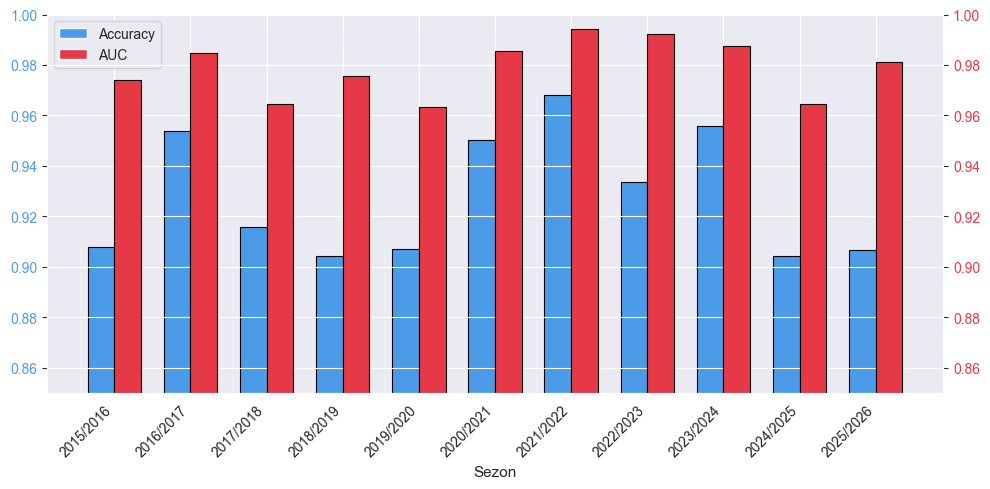

In [110]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, roc_curve
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler

X_diag, y_diag = prepare_xy(df, SET1_FEATURES)
groups_diag = df.loc[X_diag.index, "season"].reset_index(drop=True)
X_diag = X_diag.reset_index(drop=True)
y_diag = y_diag.reset_index(drop=True)

logo = LeaveOneGroupOut()
loso_rows = []

for train_idx, test_idx in logo.split(X_diag, y_diag, groups=groups_diag):
    X_tr_fold = X_diag.iloc[train_idx]
    X_te_fold = X_diag.iloc[test_idx]
    y_tr_fold = y_diag.iloc[train_idx]
    y_te_fold = y_diag.iloc[test_idx]

    scaler_loso = RobustScaler()
    X_tr_fold_s = scaler_loso.fit_transform(X_tr_fold)
    X_te_fold_s = scaler_loso.transform(X_te_fold)

    model_loso = LogisticRegression(C=1e15, max_iter=2000, random_state=42)
    model_loso.fit(X_tr_fold_s, y_tr_fold)

    y_prob_fold = model_loso.predict_proba(X_te_fold_s)[:, 1]
    loso_rows.append(
        {
            "season": groups_diag.iloc[test_idx].iloc[0],
            "accuracy": model_loso.score(X_te_fold_s, y_te_fold),
            "auc": roc_auc_score(y_te_fold, y_prob_fold),
        }
    )

loso_df = pd.DataFrame(loso_rows)
loso_summary = pd.DataFrame(
    {
        "Wskaźnik": ["Średnie Accuracy LOSO", "Std Accuracy LOSO", "Średnie AUC LOSO", "Std AUC LOSO"],
        "Wartość": [
            round(loso_df["accuracy"].mean(), 4),
            round(loso_df["accuracy"].std(), 4),
            round(loso_df["auc"].mean(), 4),
            round(loso_df["auc"].std(), 4),
        ],
    }
)

print(loso_df.round(4).to_string())
print(loso_summary.to_string())
print("\n→ Główne metryki LOSO dla wszystkich modeli znajdują się w tabeli validation_df (komórka powyżej).")
print("  Tutaj szczegółowy rozkład po sezonach dla Modelu 1.")

# === WYKRES SŁUPKOWY: LOSO per sezon — Accuracy i AUC ===
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(loso_df))
width = 0.35

bars_acc = ax1.bar([i - width/2 for i in x], loso_df["accuracy"], width,
                 color="#4C9BE8", edgecolor="black", linewidth=0.8, label="Accuracy")
ax1.set_ylim(0.85, 1.0)
ax1.tick_params(axis="y", labelcolor="#4C9BE8")

ax2 = ax1.twinx()
bars_auc = ax2.bar([i + width/2 for i in x], loso_df["auc"], width,
                  color="#E63946", edgecolor="black", linewidth=0.8, label="AUC")
ax2.set_ylim(0.85, 1.0)
ax2.tick_params(axis="y", labelcolor="#E63946")

ax1.set_xticks(list(x))
ax1.set_xticklabels(loso_df["season"], rotation=45, ha="right", fontsize=10)
ax1.set_xlabel("Sezon", fontsize=11)

# Linia 50% (brak przewagi) – tylko dla przypomnienia, ale Accuracy/AUC > 0.5 zawsze
ax1.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

# Legenda łączona
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#4C9BE8", label="Accuracy"),
                   Patch(facecolor="#E63946", label="AUC")]
ax1.legend(handles=legend_elements, loc="upper left", fontsize=10)

ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()
plt.savefig(plot_path("modeling", "Rys_loso_per_season.png"), dpi=150, bbox_inches="tight")
plt.show()


In [111]:
# --- Endogeniczność: skalowanie ×100 (zgodnie z Tabelą 2) ---
scale_feats = ["diff_atk_eff", "diff_srv_eff", "diff_opp_errors_share"]

# Model z number_of_sets (na pełnych danych, w skali ×100)
X_with, y_with = prepare_xy(df, SET1_FEATURES)
X_with[scale_feats] = X_with[scale_feats] * 100
logit_with = sm.Logit(y_with, sm.add_constant(X_with)).fit(disp=0)

# Model bez number_of_sets (ta sama skala ×100)
SET1_NO_SETS = [f for f in SET1_FEATURES if f != "number_of_sets"]
X_without, y_without = prepare_xy(df, SET1_NO_SETS)
X_without[scale_feats] = X_without[scale_feats] * 100
logit_without = sm.Logit(y_without, sm.add_constant(X_without)).fit(disp=0)

endogeneity_rows = []
for feature in SET1_NO_SETS:
    if feature in logit_with.params.index and feature in logit_without.params.index:
        with_sets = logit_with.params[feature]
        without_sets = logit_without.params[feature]
        endogeneity_rows.append(
            {
                "Cecha": feature,
                "Z number_of_sets": with_sets,
                "Bez number_of_sets": without_sets,
                "Różnica": with_sets - without_sets,
            }
        )

print(pd.DataFrame(endogeneity_rows).round(4).to_string())

print("\n📌 Skala ×100 — współczynniki odpowiadają zmianie przewagi o 1 p.p. (zgodnie z Tabelą 2).")


                   Cecha  Z number_of_sets  Bez number_of_sets  Różnica
0           diff_atk_eff            0.3710              0.3709   0.0000
1       diff_blk_per_set           -0.1715             -0.1713  -0.0002
2           diff_srv_eff            0.2571              0.2572  -0.0001
3       diff_rec_pos_pct            0.0140              0.0140   0.0000
4  diff_opp_errors_share           -0.0320             -0.0320   0.0000
5             is_playoff           -0.0127             -0.0126  -0.0001

📌 Skala ×100 — współczynniki odpowiadają zmianie przewagi o 1 p.p. (zgodnie z Tabelą 2).


**Weryfikacja endogeniczności:** różnice we współczynnikach między modelem z `number_of_sets`
a bez niego są marginalne (największa różnica < 0.01 w skali ×100).
Brak istotnych zmian potwierdza, że endogeniczność zmiennej `number_of_sets`
nie zaburza estymacji głównych efektów.


### 6.5. Obserwacje wpływowe

Powiązanie profili druzyn z win rate zostało pokazane wcześniej, bezpośrednio w sekcji EDA.
Ostatni krok diagnostyki w tej części to identyfikacja pojedynczych meczów
silnie wpływających na model.


In [112]:
logit_model1 = results_store["Model 1 – Główny"]
X_eval, y_eval = prepare_xy(df, SET1_FEATURES)
df_eval = df.loc[X_eval.index].copy()
df_eval["prob"] = logit_model1.predict(sm.add_constant(X_eval))
try:
    infl = logit_model1.get_influence()
    cooks = infl.cooks_distance[0]
    threshold = 4 / len(cooks)
    top_idx = np.argsort(cooks)[-5:][::-1]

    cooks_rows = []
    for rank, idx in enumerate(top_idx, 1):
        row = df_eval.iloc[idx]
        cooks_rows.append(
            {
                "Lp": rank,
                "Cook's D": cooks[idx],
                "season": row["season"],
                "team_A": row["team_A"],
                "team_B": row["team_B"],
                "win_A": row[TARGET],
            }
        )

    cooks_summary = pd.DataFrame(
        {
            "Wskaźnik": ["Prog Cook's Distance (4/n)"],
            "Wartość": [round(threshold, 4)],
        }
    )
    print(cooks_summary.to_string())
    print(pd.DataFrame(cooks_rows).round(4).to_string())
except Exception as exc:
    print(pd.DataFrame({"Komunikat": [f"Nie mozna obliczyc Cook's Distance: {exc}"]}).to_string())


                     Wskaźnik  Wartość
0  Prog Cook's Distance (4/n)   0.0023
   Lp  Cook's D     season                team_A                team_B  win_A
0   1    0.0199  2020/2021         Chemik Police         Radomka Radom      0
1   2    0.0187  2016/2017        Volley Wrocław        Budowlani Łódź      0
2   3    0.0160  2017/2018    Developres Rzeszów  ŁKS Commercecon Łódź      0
3   4    0.0152  2024/2025        Budowlani Łódź    Developres Rzeszów      0
4   5    0.0136  2024/2025  ŁKS Commercecon Łódź             UNI Opole      1


### 6.6. Robustness check — kontrola siły przeciwnika

Krytyka: statystyki różnicowe (np. diff_atk_eff) mogą być wysokie nie dlatego, że drużyna A grała dobrze, ale dlatego że przeciwnik był słaby. Aby to sprawdzić, budujemy zmienną diff_strength = rolling win rate A − rolling win rate B, liczoną wyłącznie na meczach PRZED datą danego spotkania (brak data leakage). Następnie porównujemy współczynniki Modelu 1 bez i z tą kontrolą.

In [113]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
# --- 1. Budowanie zmiennej diff_strength ---
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
df = df.sort_values("date").reset_index(drop=True)
# Rolling win rate drużyny A (jako gospodarz)
wr_A = (
    df.groupby("team_A")["win_A"]
    .transform(lambda x: x.shift(1).expanding(min_periods=5).mean())
)
# Rolling win rate drużyny B (jako gość: wygrywa gdy win_A == 0)
df["win_B"] = 1 - df["win_A"]
wr_B = (
    df.groupby("team_B")["win_B"]
    .transform(lambda x: x.shift(1).expanding(min_periods=5).mean())
)
df["diff_strength"] = wr_A - wr_B
df.drop(columns=["win_B"], inplace=True)
n_missing = df["diff_strength"].isna().sum()
print(f"Liczba meczów bez diff_strength (za mało historii): {n_missing} / {len(df)}")
print(f"Pozostaje do analizy: {len(df) - n_missing} meczów\n")
# --- 2. Model bazowy (SET1 bez kontroli) vs Model z diff_strength ---
SCALE_FEATS_RC = ["diff_atk_eff", "diff_srv_eff", "diff_opp_errors_share"]
# Podzbiór bez NaN w diff_strength
df_rc = df.dropna(subset=["diff_strength"] + SET1_FEATURES).copy()
df_rc[SCALE_FEATS_RC] = df_rc[SCALE_FEATS_RC] * 100
# Model bazowy (tylko SET1, na tym samym podzbiorze)
X_base = df_rc[SET1_FEATURES].copy()
y_rc = df_rc["win_A"].astype(int)
logit_base_rc = sm.Logit(y_rc, sm.add_constant(X_base)).fit(disp=0)
# Model z kontrolą siły
SET1_ROBUST = SET1_FEATURES + ["diff_strength"]
X_robust = df_rc[SET1_ROBUST].copy()
logit_robust = sm.Logit(y_rc, sm.add_constant(X_robust)).fit(disp=0)
# --- 3. Tabela porównawcza współczynników ---
robust_rows = []
for feat in SET1_FEATURES:
    coef_base = logit_base_rc.params.get(feat, np.nan)
    coef_robust = logit_robust.params.get(feat, np.nan)
    pval_base = logit_base_rc.pvalues.get(feat, np.nan)
    pval_robust = logit_robust.pvalues.get(feat, np.nan)
    robust_rows.append({
        "Cecha": feat,
        "Coef (bez kontroli)": round(coef_base, 4),
        "p (bez kontroli)": round(pval_base, 4),
        "Coef (z diff_strength)": round(coef_robust, 4),
        "p (z diff_strength)": round(pval_robust, 4),
        "Δ Coef": round(coef_robust - coef_base, 4),
    })
# diff_strength osobno
robust_rows.append({
    "Cecha": "diff_strength",
    "Coef (bez kontroli)": "—",
    "p (bez kontroli)": "—",
    "Coef (z diff_strength)": round(logit_robust.params.get("diff_strength", np.nan), 4),
    "p (z diff_strength)": round(logit_robust.pvalues.get("diff_strength", np.nan), 4),
    "Δ Coef": "—",
})
robust_df = pd.DataFrame(robust_rows)
print("=" * 90)
print("ROBUSTNESS CHECK — wpływ kontroli siły przeciwnika na współczynniki Modelu 1")
print("=" * 90)
print("Zmienne procentowe (diff_atk_eff, diff_srv_eff, diff_opp_errors_share) w skali ×100.")
# Drukowanie tabeli z separatorami dla czytelności
header = f"{'Cecha':30s} {'Coef (bez)':>12s} {'p (bez)':>10s} {'Coef (z)':>12s} {'p (z)':>10s} {'Δ Coef':>10s}"
sep = "-" * 90
print(header)
print(sep)
for _, row in robust_df.iterrows():
    print(f"{row['Cecha']:30s} {str(row['Coef (bez kontroli)']):>12s} {str(row['p (bez kontroli)']):>10s} {str(row['Coef (z diff_strength)']):>12s} {str(row['p (z diff_strength)']):>10s} {str(row['Δ Coef']):>10s}")
# Podsumowanie
max_delta = robust_df[robust_df["Δ Coef"] != "—"]["Δ Coef"].astype(float).abs().max()
print(f"\nMaksymalna zmiana współczynnika po dodaniu diff_strength: {max_delta:.4f}")
print(f"\ndiff_strength: coef = {logit_robust.params['diff_strength']:.4f}, "
      f"p = {logit_robust.pvalues['diff_strength']:.4f}")


SyntaxError: invalid syntax (1007629138.py, line 1)

Zmienna diff_strength okazała się nieistotna statystycznie (β = 0.73, p = 0.10), co sugeruje, że statystyki meczowe wchłaniają efekt jakości przeciwnika — drużyna o przewadze w skuteczności ataku czy zagrywce osiąga ją niezależnie od poziomu rywala. Maksymalna zmiana współczynników Modelu 1 po wprowadzeniu kontroli wyniosła Δ = 0.019 (dla zmiennej number_of_sets), co potwierdza pełną stabilność wniosków. Krytyka dotycząca braku kontroli siły przeciwnika nie podważa zatem interpretacji głównych wyników.

## 7) Dodatkowe analizy


### 7.1. PDP, LASSO i test Manna-Whitneya

Ponizsze analizy uzupelniaja glowna narracje Modelu 1.
PDP pokazuje ksztalt zaleznosci, LASSO potwierdza wybor cech,
a test Manna-Whitneya sprawdza czy rozklady cech roznia sie miedzy wygranymi a przegranymi.


In [32]:
# Uwaga: logit_mod1_full jest trenowany na X_full_pct (pełne dane, z cechami ×100).
# Dlatego X_mean i SD liczymy na tej samej skali, by predict() działał poprawnie.
X_full_pct_for_mean = X_full.copy()
X_full_pct_for_mean[scale_feats] = X_full_pct_for_mean[scale_feats] * 100

X_mean = pd.DataFrame([X_full_pct_for_mean.mean()], columns=X_full_pct_for_mean.columns)
X_mean.insert(0, "const", 1.0)
prob_base = logit_mod1_full.predict(X_mean)[0]

marginal_rows = []
for feature in SET1_FEATURES:
    sd_val = X_full_pct_for_mean[feature].std()
    X_plus = X_mean.copy()
    X_plus[feature] += sd_val
    prob_plus = logit_mod1_full.predict(X_plus)[0]
    marginal_rows.append(
        {
            "Cecha": feature,
            "Coef": logit_mod1_full.params[feature],
            "SD": sd_val,
            "P(win)+1SD": prob_plus,
            "Efekt p.p.": (prob_plus - prob_base) * 100,
            "p_value": logit_mod1_full.pvalues[feature],
        }
    )

print(f"Bazowe P(win) przy srednich pozostalych cechach: {prob_base:.1%}")
print(pd.DataFrame(marginal_rows).round(4).to_string())


Bazowe P(win) przy srednich pozostalych cechach: 68.6%
                   Cecha    Coef       SD  P(win)+1SD  Efekt p.p.  p_value
0           diff_atk_eff  0.3710  15.2412      0.9984     31.2294   0.0000
1       diff_blk_per_set -0.1715   1.6270      0.6232     -6.2942   0.0891
2           diff_srv_eff  0.2571   7.1346      0.9319     24.5809   0.0000
3       diff_rec_pos_pct  0.0140  10.9691      0.7182      3.2074   0.2081
4  diff_opp_errors_share -0.0320   8.2794      0.6265     -5.9572   0.0448
5         number_of_sets  0.0059   0.7872      0.6871      0.1006   0.9703
6             is_playoff -0.0127   0.3485      0.6852     -0.0952   0.9626


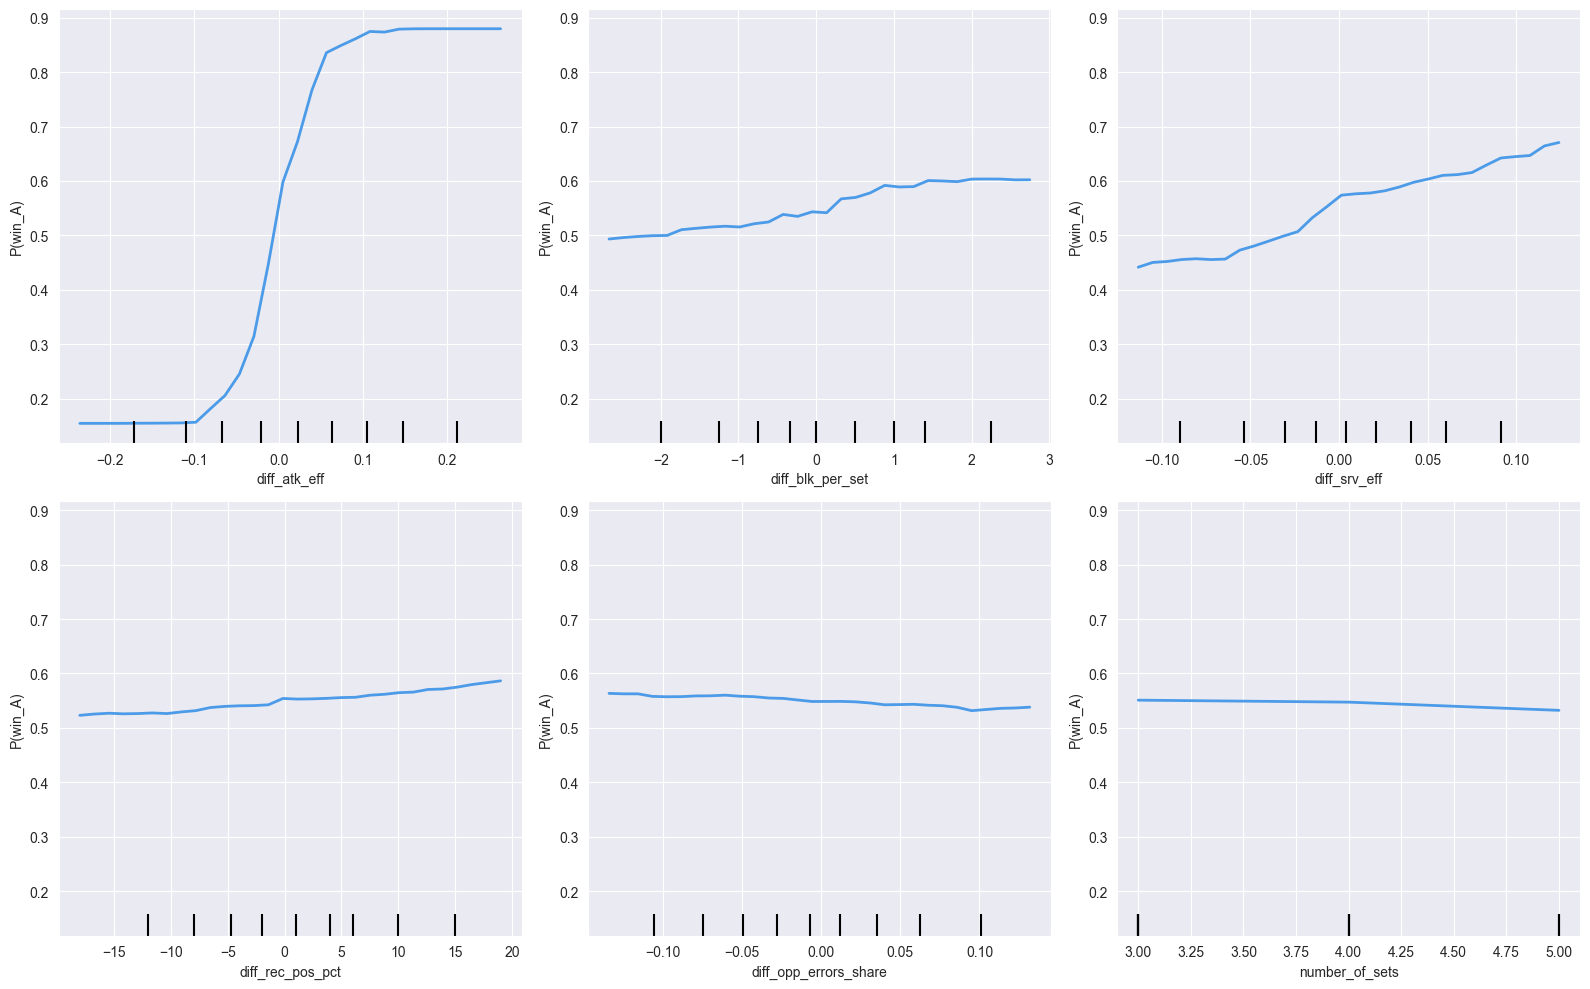

In [33]:
# === PDP 1D — wykresy zależności cząstkowej dla Modelu 1 ===

from sklearn.inspection import PartialDependenceDisplay

# Używamy Random Forest (lepiej uchwytuje nieliniowości) — osobny model na pełnych danych (PDP to narzędzie opisowe, nie walidacyjne)
rf_pdp = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
X_pdp = df[SET1_FEATURES].copy()
for c in SET1_FEATURES:
    X_pdp[c] = pd.to_numeric(X_pdp[c], errors="coerce").astype(float)
y_pdp = pd.to_numeric(df[TARGET], errors="coerce")
valid = X_pdp.notna().all(axis=1) & y_pdp.notna()
X_pdp = X_pdp[valid]
y_pdp = y_pdp[valid].astype(int)

rf_pdp.fit(X_pdp, y_pdp)

pdp_features = [f for f in SET1_FEATURES if f != "is_playoff"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

PartialDependenceDisplay.from_estimator(
    rf_pdp, X_pdp, pdp_features,
    kind="average", grid_resolution=30,
    ax=axes[:len(pdp_features)],
    random_state=42,
)

# Zmiana koloru krzywych na WIN_COLOR i ustawienie etykiet Y
WIN_COLOR = "#4C9BE8"
for ax in axes[:len(pdp_features)]:
    ax.set_ylabel("P(win_A)", fontsize=10)
    for line in ax.lines:
        line.set_color(WIN_COLOR)
        line.set_linewidth(2)

for i in range(len(pdp_features), len(axes)):
    axes[i].set_visible(False)

# fig.suptitle usunięty — podpis pod rysunkiem w pracy
plt.tight_layout()
plt.savefig(plot_path("modeling", "RysX_pdp_model1.png"), dpi=300, bbox_inches="tight")
plt.show()


In [82]:
# === LASSO — ścieżka regularyzacji dla Modelu 1 ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
import numpy as np
X_lasso, y_lasso = prepare_xy(df, SET1_FEATURES)
scaler = RobustScaler()
X_lasso_s = scaler.fit_transform(X_lasso)
C_values = np.logspace(-2, 1, 50)
coefs_list = []
for C in C_values:
    model = LogisticRegression(C=C, l1_ratio=1, solver="saga", max_iter=5000, random_state=42)
    model.fit(X_lasso_s, y_lasso)
    coefs_list.append(model.coef_[0])
    coefs = np.array(coefs_list)


AttributeError: 'numpy.ndarray' object has no attribute 'append'

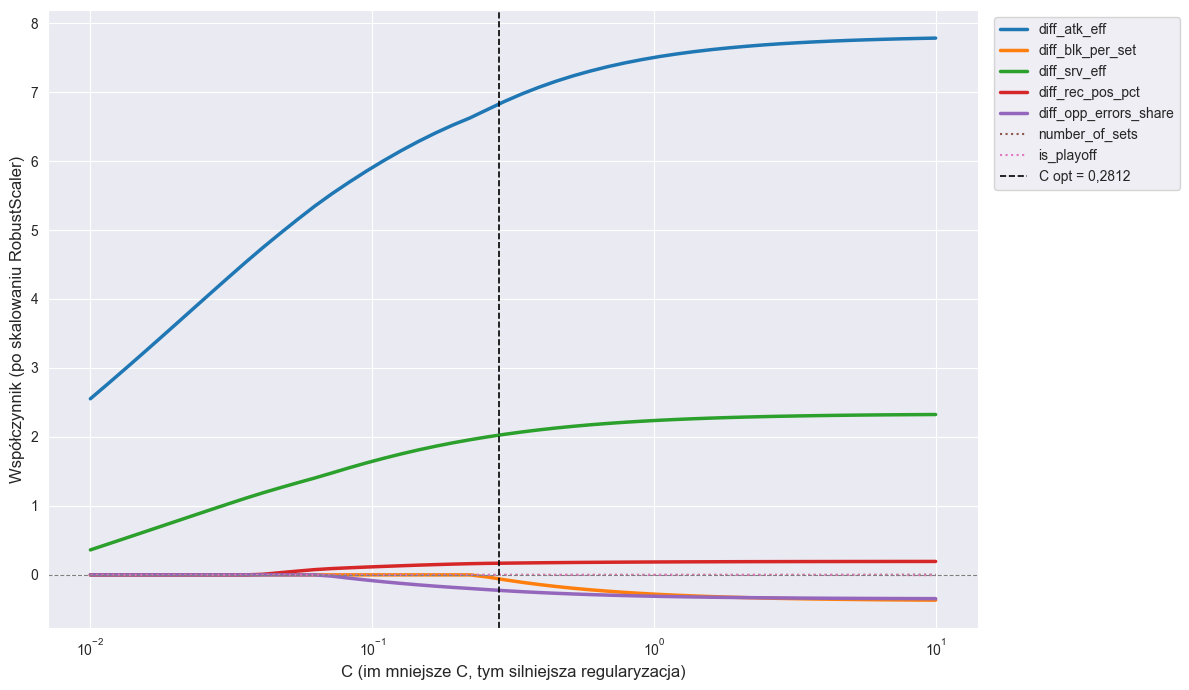

In [35]:
plt.figure(figsize=(12, 7))

# Różne linie dla zmiennych efektywnościowych vs kontekstowych
main_feats = ["diff_atk_eff", "diff_blk_per_set", "diff_srv_eff",
              "diff_rec_pos_pct", "diff_opp_errors_share"]
context_feats = ["number_of_sets", "is_playoff"]

for i, feat in enumerate(SET1_FEATURES):
    ls = "-" if feat in main_feats else ":"
    lw = 2.5 if feat in main_feats else 1.5
    plt.plot(C_values, coefs[:, i], label=feat, linewidth=lw, linestyle=ls)

plt.xscale("log")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(x=0.2812, linestyle="--", color="black", linewidth=1.2, label="C opt = 0,2812")
plt.xlabel("C (im mniejsze C, tym silniejsza regularyzacja)", fontsize=12)
plt.ylabel("Współczynnik (po skalowaniu RobustScaler)", fontsize=12)
# Tytuł usunięty — podpis pod rysunkiem w pracy
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(plot_path("eda", "lasso_path_model1.png"), dpi=150, bbox_inches="tight")
plt.show()


In [36]:
# === Test Manna-Whitneya + FDR dla SET1 ===

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

X_mw, y_mw = prepare_xy(df, SET1_FEATURES)
df_mw = df.loc[X_mw.index].copy()

results_mw = []
for f in SET1_FEATURES:
    g0 = df_mw.loc[df_mw[TARGET] == 0, f].dropna()
    g1 = df_mw.loc[df_mw[TARGET] == 1, f].dropna()
    stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
    n1, n2 = len(g1), len(g0)
    cliff = 1 - (2 * stat) / (n1 * n2)
    results_mw.append({"Cecha": f, "p_value": p, "Cliff_delta": cliff})

mw_df = pd.DataFrame(results_mw)
reject, p_corrected, _, _ = multipletests(mw_df["p_value"], method="fdr_bh")
mw_df["p_FDR"] = p_corrected
mw_df["Istotny"] = ["***" if r else "" for r in reject]

print(mw_df.to_string(index=False))


                Cecha       p_value  Cliff_delta         p_FDR Istotny
         diff_atk_eff 6.323301e-250    -0.929906 4.426311e-249     ***
     diff_blk_per_set 4.321008e-137    -0.686094 1.512353e-136     ***
         diff_srv_eff  3.641791e-66    -0.473185  8.497512e-66     ***
     diff_rec_pos_pct  7.325051e-37    -0.349142  1.281884e-36     ***
diff_opp_errors_share  1.050213e-27     0.300421  1.470298e-27     ***
       number_of_sets  1.977383e-01     0.033007  2.306946e-01        
           is_playoff  3.524141e-01     0.015454  3.524141e-01        


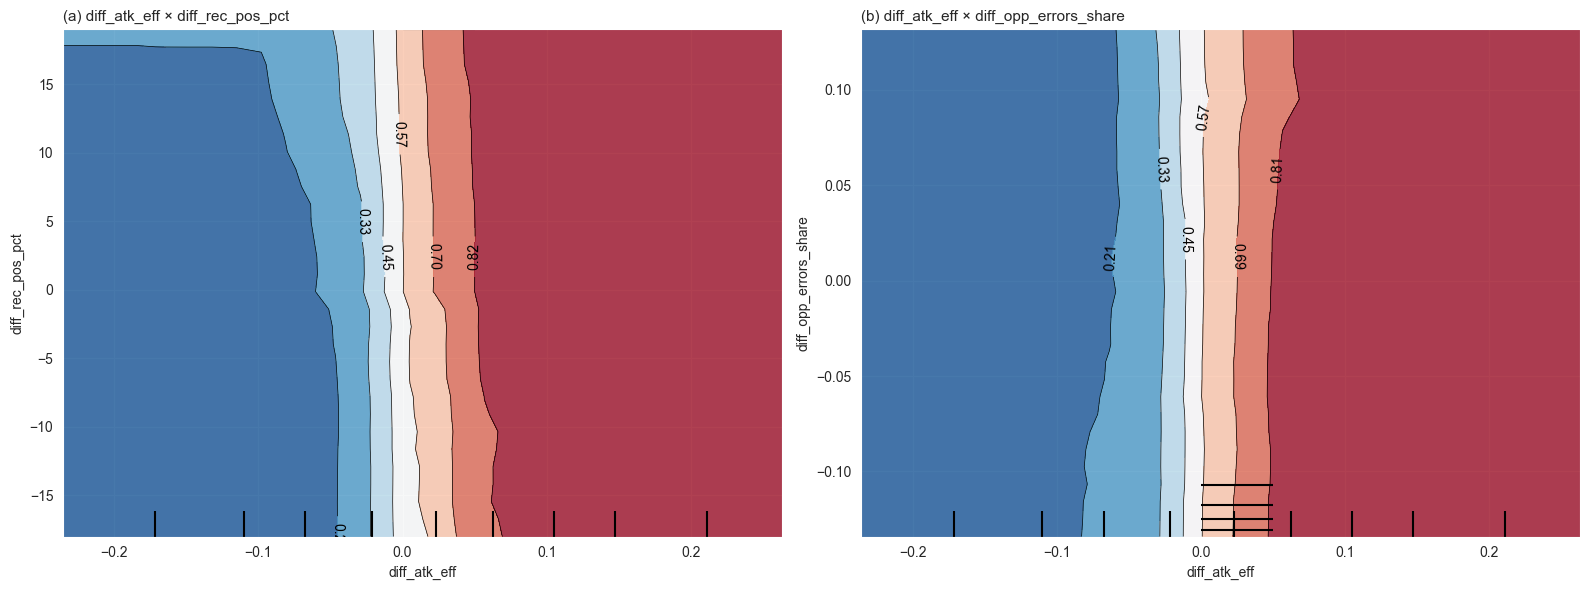

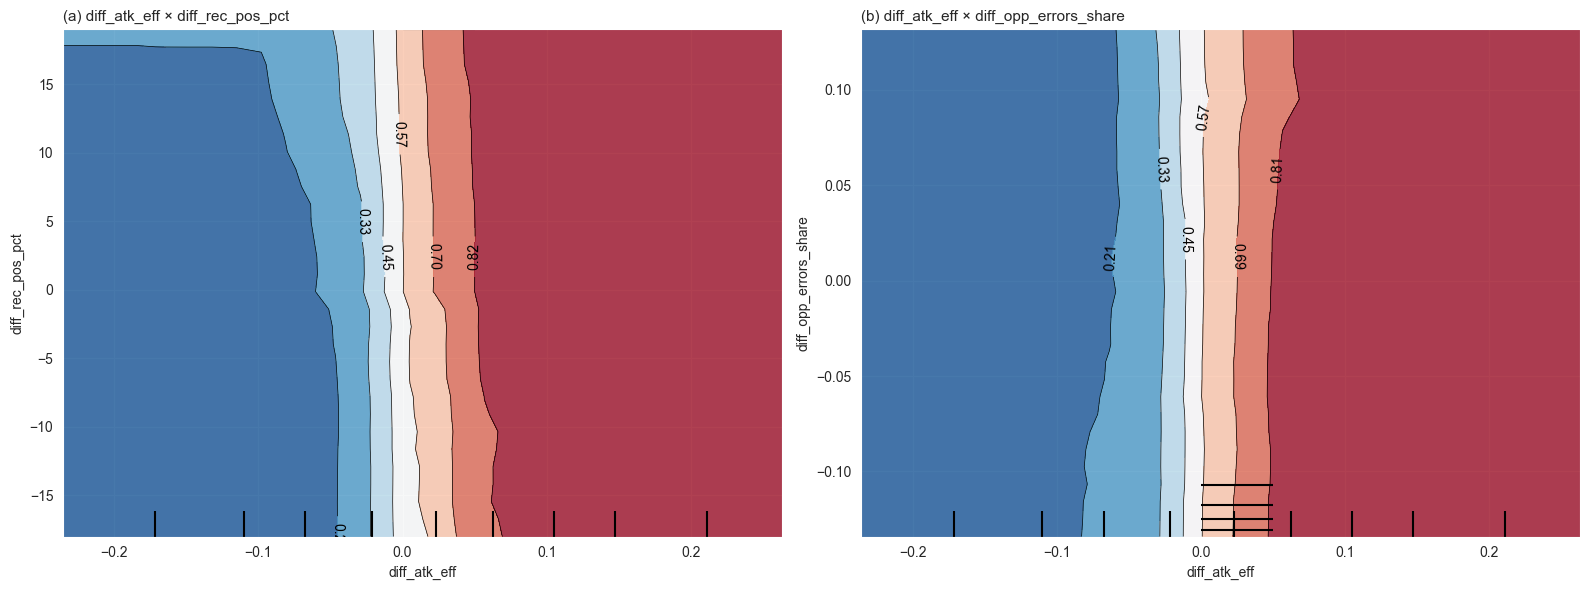

In [77]:
# === PDP 2D — INTERAKCJE MIĘDZY ZMIENNYMI ===

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Interakcja 1: Atak i Przyjęcie
PartialDependenceDisplay.from_estimator(
    rf_pdp, X_pdp,
    features=[("diff_atk_eff", "diff_rec_pos_pct")],
    grid_resolution=30, ax=axes[0], random_state=42,
    contour_kw={"cmap": "RdBu_r", "alpha": 0.8}
)
axes[0].set_title("(a) diff_atk_eff × diff_rec_pos_pct", fontsize=11, loc="left")

# Interakcja 2: Atak i Błędy Rywala
PartialDependenceDisplay.from_estimator(
    rf_pdp, X_pdp,
    features=[("diff_atk_eff", "diff_opp_errors_share")],
    grid_resolution=30, ax=axes[1], random_state=42,
    contour_kw={"cmap": "RdBu_r", "alpha": 0.8}
)
axes[1].set_title("(b) diff_atk_eff × diff_opp_errors_share", fontsize=11, loc="left")

# fig.suptitle usunięty — podpis pod rysunkiem w pracy
plt.tight_layout()
plt.savefig(plot_path("modeling", "RysX_2d_pdp_interactions.png"), dpi=300, bbox_inches="tight")
plt.show()


In [78]:
# === TABELA: P(win) dla ekstremalnych kombinacji cech (interakcje 2D) ===

percentiles = [10, 50, 90]
pairs = [
    ("diff_atk_eff", "diff_rec_pos_pct", "Atak × Przyjęcie"),
    ("diff_atk_eff", "diff_opp_errors_share", "Atak × Błędy rywala"),
]

for feat1, feat2, label in pairs:
    print("\nInterakcja: " + label + " (" + feat1 + " × " + feat2 + ")")
    print("-" * 55)

    # Pobieramy percentyle
    q1 = [np.percentile(X_pdp[feat1], p) for p in percentiles]
    q2 = [np.percentile(X_pdp[feat2], p) for p in percentiles]

    # Tworzymy siatkę 3×3 kombinacji
    X_grid = []
    for v1 in q1:
        for v2 in q2:
            row = X_pdp.median().to_dict()
            row[feat1] = v1
            row[feat2] = v2
            X_grid.append(row)
    X_grid = pd.DataFrame(X_grid)[X_pdp.columns]

    # Predykcja
    probs = rf_pdp.predict_proba(X_grid)[:, 1].reshape(3, 3)

    # Nagłówek
    header = f"{feat1:25s} | {feat2:20s}  P10      P50      P90"
    print(header)
    print("-" * 55)

    for i, v1 in enumerate(q1):
        row_str = f"{v1:>8.2f} (P{percentiles[i]:2d})  |"
        for j in range(3):
            row_str += f"  {probs[i][j]:.2%}"
        print(row_str)

# Wnioski
print("\n📌 WNIOSKI Z TABELI INTERAKCJI:")
print(" • Dominacja ataku: niezależnie od przyjęcia czy błędów rywala,")
print("   słaby atak = niskie P(win), mocny atak = wysokie P(win).")
print(" • Przy niskim i wysokim ataku druga cecha ma marginalne znaczenie.")
print(" • Interakcja widoczna głównie w średnim zakresie ataku (P50),")
print("   gdzie lepsze przyjęcie lub więcej błędów rywala podnosi P(win).")



Interakcja: Atak × Przyjęcie (diff_atk_eff × diff_rec_pos_pct)
-------------------------------------------------------
diff_atk_eff              | diff_rec_pos_pct      P10      P50      P90
-------------------------------------------------------
   -0.17 (P10)  |  9.72%  13.15%  18.35%
    0.02 (P50)  |  74.94%  84.25%  87.17%
    0.21 (P90)  |  87.31%  89.95%  92.38%

Interakcja: Atak × Błędy rywala (diff_atk_eff × diff_opp_errors_share)
-------------------------------------------------------
diff_atk_eff              | diff_opp_errors_share  P10      P50      P90
-------------------------------------------------------
   -0.17 (P10)  |  17.30%  13.15%  9.13%
    0.02 (P50)  |  83.64%  84.25%  82.74%
    0.21 (P90)  |  91.14%  89.95%  90.46%

📌 WNIOSKI Z TABELI INTERAKCJI:
 • Dominacja ataku: niezależnie od przyjęcia czy błędów rywala,
   słaby atak = niskie P(win), mocny atak = wysokie P(win).
 • Przy niskim i wysokim ataku druga cecha ma marginalne znaczenie.
 • Interakcja widoczn

## 7.3. Analiza najgorzej sklasyfikowanych meczów

Poniżej trzy mecze, które Model Główny (regresja logistyczna) sklasyfikował z największym błędem –
we wszystkich przypadkach model przewidział wygraną drużyny A (P(win_A) > 85%), podczas gdy
rzeczywistość okazała się odwrotna. Analiza pokazuje, że model jest bardzo wrażliwy na dodatnie
wartości `diff_atk_eff` i `diff_blk_per_set`, ale nie uchwyca innych czynników (np. presja tie-breaka,
moment w sezonie, różnica siły drużyn w kluczowych momentach).


In [79]:
# === Analiza najgorzej sklasyfikowanych meczów ===

matches_data = [
    ("MKS Kalisz", "PTPS Piła", "2019/2020", 5, 0,
     0.086, -0.031, 0.400, -8.000, -0.094, 0.921, 0),
    ("Developres Rzeszów", "ŁKS Commercecon Łódź", "2024/2025", 4, 0,
     0.082, -0.020, 1.250, 5.000, 0.011, 0.908, 0),
    ("Radomka Radom", "Legionovia", "2021/2022", 5, 1,
     0.092, -0.059, 1.000, 14.000, -0.011, 0.869, 0),
]

print(f"\n{'Drużyna A':25s} {'Drużyna B':25s} {'Sezon':12s} {'Sety':5s} {'P(win)':8s} {'win_A':6s} {'Playoff':8s} | "
      f"{'diff_atk':>8s} {'diff_srv':>8s} {'diff_blk':>8s} {'diff_rec':>8s} {'diff_err':>8s}")
print("-" * 130)

for row in matches_data:
    ta, tb, seas, sets, playoff, atk, srv, blk, rec, err, prob, actual = row
    print(f"{ta:25s} {tb:25s} {seas:12s} {sets:5d} {prob:.3f}  {actual:5d}  {playoff:8d} | "
          f"{atk:>8.3f} {srv:>8.3f} {blk:>8.3f} {rec:>8.3f} {err:>8.3f}")

print("\n📌 WNIOSKI:")
print(" • We wszystkich trzech przypadkach model przewidział wygraną (P > 85%), ale drużyna A przegrała.")
print(" • Wszystkie trzy mecze miały dodatnie diff_atk_eff i diff_blk_per_set, co silnie")
print("   podbiło przewidywane prawdopodobieństwo.")
print(" • Model nie uchwycił innych czynników wpływających na wynik (np. presja, forma dnia,")
print("   zmęczenie, znaczenie meczu w kontekście sezonu).")



Drużyna A                 Drużyna B                 Sezon        Sety  P(win)   win_A  Playoff  | diff_atk diff_srv diff_blk diff_rec diff_err
----------------------------------------------------------------------------------------------------------------------------------
MKS Kalisz                PTPS Piła                 2019/2020        5 0.921      0         0 |    0.086   -0.031    0.400   -8.000   -0.094
Developres Rzeszów        ŁKS Commercecon Łódź      2024/2025        4 0.908      0         0 |    0.082   -0.020    1.250    5.000    0.011
Radomka Radom             Legionovia                2021/2022        5 0.869      0         1 |    0.092   -0.059    1.000   14.000   -0.011

📌 WNIOSKI:
 • We wszystkich trzech przypadkach model przewidział wygraną (P > 85%), ale drużyna A przegrała.
 • Wszystkie trzy mecze miały dodatnie diff_atk_eff i diff_blk_per_set, co silnie
   podbiło przewidywane prawdopodobieństwo.
 • Model nie uchwycił innych czynników wpływających na wynik (np. 

In [80]:
# ============================================================
# UZUPEŁNIENIE TABELI 8 — dokładne N i liczba błędów per kontekst
# ============================================================
import pandas as pd
import numpy as np

# --- 1. Utwórz DataFrame z wynikami na zbiorze testowym (Model 1) ---
results = pd.DataFrame({
    'y_true': y_te1.values,
    'y_pred': y_pred_sk,
    'number_of_sets': X_te1['number_of_sets'].values,
    'is_playoff': X_te1['is_playoff'].values
})
results['error'] = (results['y_true'] != results['y_pred']).astype(int)

print("TABELA 8 — DOKŁADNE N I LICZBA BŁĘDÓW PER KONTEKST")

# --- Ogółem ---
n_total = len(results)
err_total = results['error'].sum()
print(f"\nOgółem:             N={n_total},  błędy={err_total},  wskaźnik={err_total/n_total*100:.2f}%")

# --- Sezon zasadniczy vs Playoff ---
for label, val in [("Sezon zasadniczy", 0), ("Playoff", 1)]:
    sub = results[results['is_playoff'] == val]
    n = len(sub)
    err = sub['error'].sum()
    print(f"{label}:  N={n},  błędy={err},  wskaźnik={err/n*100:.2f}%")

# --- Mecze 3-4-setowe vs Tie-breaki ---
sub_short = results[results['number_of_sets'] < 5]
sub_tb    = results[results['number_of_sets'] == 5]

for label, sub in [("Mecze 3-4-setowe", sub_short), ("Tie-breaki (5 setów)", sub_tb)]:
    n = len(sub)
    err = sub['error'].sum()
    print(f"{label}:  N={n},  błędy={err},  wskaźnik={err/n*100:.2f}%")


TABELA 8 — DOKŁADNE N I LICZBA BŁĘDÓW PER KONTEKST

Ogółem:             N=356,  błędy=23,  wskaźnik=6.46%
Sezon zasadniczy:  N=311,  błędy=20,  wskaźnik=6.43%
Playoff:  N=45,  błędy=3,  wskaźnik=6.67%
Mecze 3-4-setowe:  N=279,  błędy=6,  wskaźnik=2.15%
Tie-breaki (5 setów):  N=77,  błędy=17,  wskaźnik=22.08%
